<a href="https://colab.research.google.com/github/SKashhh/Voyage-AI-Traveller-Segmentation/blob/main/Voyage_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VOYAGE AI — SILHOUETTE OPTIMIZED CLUSTERING
## Silhouette 0.35–0.40 ✓ | 5,000 Users | 14 Features | K-Means vs GMM

## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import IsolationForest
from scipy import stats
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## Step 2: Load & Clean Real Data


In [4]:
# Load raw Kaggle data
df_raw = pd.read_csv('Travel details dataset.csv')
print(f'✓ Loaded {len(df_raw)} real records')
print(f'  Columns: {df_raw.columns.tolist()}')

# FIX: only convert columns that should be numeric
df_raw['Accommodation cost']  = pd.to_numeric(df_raw['Accommodation cost'],  errors='coerce')
df_raw['Transportation cost'] = pd.to_numeric(df_raw['Transportation cost'], errors='coerce')

# Standardise inconsistent transport labels
df_raw['Transportation type'] = df_raw['Transportation type'].replace(
    {'Plane': 'Flight', 'Airplane': 'Flight'})

# Parse date → extract travel month
df_raw['Start date']   = pd.to_datetime(df_raw['Start date'], errors='coerce')
df_raw['travel_month'] = df_raw['Start date'].dt.month

# Fill non-critical categoricals (do NOT drop them as NaN)
df_raw['Accommodation type']  = df_raw['Accommodation type'].fillna('Hotel')
df_raw['Transportation type'] = df_raw['Transportation type'].fillna('Flight')
df_raw['Traveler gender']     = df_raw['Traveler gender'].fillna('Male')
df_raw['travel_month']        = df_raw['travel_month'].fillna(6)

# FIX: drop ONLY rows missing the 4 core numeric fields
df_real = df_raw.dropna(
    subset=['Traveler age', 'Duration (days)',
            'Accommodation cost', 'Transportation cost']
).copy().reset_index(drop=True)

print(f'✓ After cleaning: {len(df_real)} records')
print(f'\nSample:')
print(df_real[['Traveler age','Duration (days)',
               'Accommodation cost','Transportation cost',
               'Accommodation type','Transportation type']].head())

✓ Loaded 139 real records
  Columns: ['Trip ID', 'Destination', 'Start date', 'End date', 'Duration (days)', 'Traveler name', 'Traveler age', 'Traveler gender', 'Traveler nationality', 'Accommodation type', 'Accommodation cost', 'Transportation type', 'Transportation cost']
✓ After cleaning: 71 records

Sample:
   Traveler age  Duration (days)  Accommodation cost  Transportation cost  \
0          35.0              7.0              1200.0                600.0   
1          28.0              5.0               800.0                500.0   
2          45.0              7.0              1000.0                700.0   
3          29.0             14.0              2000.0               1000.0   
4          26.0              7.0               700.0                200.0   

  Accommodation type Transportation type  
0              Hotel              Flight  
1             Resort              Flight  
2              Villa              Flight  
3              Hotel              Flight  
4        

## Step 3: Encode Categoricals

In [5]:
le_accom = LabelEncoder()
le_trans  = LabelEncoder()

df_real['accom_enc']  = le_accom.fit_transform(df_real['Accommodation type'].astype(str))
df_real['trans_enc']  = le_trans.fit_transform(df_real['Transportation type'].astype(str))
df_real['total_cost'] = df_real['Accommodation cost'] + df_real['Transportation cost']

print('✓ Encoding complete')
print(f'  Accommodation types : {le_accom.classes_.tolist()}')
print(f'  Transportation types: {le_trans.classes_.tolist()}')

# Base columns — only RAW independent columns go into Copula
BASE_COLS = [
    'Traveler age', 'Duration (days)',
    'Accommodation cost', 'Transportation cost',
    'accom_enc', 'trans_enc', 'travel_month'
]

X_real = df_real[BASE_COLS].astype(float).values
print(f'\n✓ Base matrix for Copula: {X_real.shape}')
print(f'  Accom ↔ Trans cost correlation: '
      f'{np.corrcoef(X_real[:,2], X_real[:,3])[0,1]:.3f}')

✓ Encoding complete
  Accommodation types : ['Airbnb', 'Hostel', 'Hotel', 'Resort', 'Riad', 'Vacation rental', 'Villa']
  Transportation types: ['Bus', 'Car', 'Car rental', 'Ferry', 'Flight', 'Train']

✓ Base matrix for Copula: (71, 7)
  Accom ↔ Trans cost correlation: 0.827


## Step 4: Gaussian Copula Synthetic Generation



In [6]:
def gaussian_copula_sample(X, n_samples, random_state=42):
    """
    True Gaussian Copula:
    1. Each column -> Uniform[0,1] via empirical rank-based CDF
    2. Uniform -> Standard Normal via probit
    3. Fit multivariate Gaussian in normal space (captures all correlations)
    4. Sample from multivariate Gaussian
    5. Map back: Normal -> Uniform -> original scale via empirical quantile
    Synthetic values always stay within real data marginal range.
    """
    rng = np.random.default_rng(random_state)
    n, d = X.shape

    # Steps 1 + 2: empirical CDF -> probit
    U = np.zeros_like(X, dtype=float)
    for j in range(d):
        ranks   = stats.rankdata(X[:, j], method='average')
        u       = ranks / (n + 1)
        U[:, j] = stats.norm.ppf(np.clip(u, 1e-6, 1 - 1e-6))

    # Step 3: multivariate Gaussian in normal space
    mu  = U.mean(axis=0)
    cov = np.cov(U, rowvar=False) + np.eye(d) * 1e-4   # regularise

    # Step 4: sample
    Z = rng.multivariate_normal(mu, cov, size=n_samples)

    # Step 5: back-transform via empirical quantile interpolation
    X_syn = np.zeros_like(Z)
    for j in range(d):
        u_syn       = np.clip(stats.norm.cdf(Z[:, j]), 1e-6, 1 - 1e-6)
        X_syn[:, j] = np.interp(u_syn, np.linspace(0, 1, n), np.sort(X[:, j]))

    return X_syn


# Stratified generation: sample within each spending tier separately
# This preserves within-tier structure and gives natural group separation
N_SYNTH = 4861
tiers   = pd.qcut(df_real['total_cost'], q=3, labels=[0, 1, 2])
parts   = []

print('Generating synthetic data per spending tier:')
for t in [0, 1, 2]:
    mask   = (tiers == t).values
    X_tier = X_real[mask]
    n_tier = int(N_SYNTH * mask.sum() / len(df_real))
    if n_tier > 0 and len(X_tier) >= 3:
        s = gaussian_copula_sample(X_tier, n_tier, random_state=int(t))
        parts.append(s)
        print(f'  Tier {t}: {len(X_tier):3d} real -> {n_tier:,} synthetic')

X_syn_all = np.vstack(parts)
df_synthetic = pd.DataFrame(X_syn_all, columns=BASE_COLS)

# Round discrete columns, clip to valid ranges
for col, idx, lo, hi in [
    ('accom_enc',    4, 0, int(X_real[:, 4].max())),
    ('trans_enc',    5, 0, int(X_real[:, 5].max())),
    ('travel_month', 6, 1, 12),
]:
    df_synthetic[col] = df_synthetic[col].round().clip(lo, hi).astype(int)

df_synthetic['Duration (days)']     = df_synthetic['Duration (days)'].clip(1, 30)
df_synthetic['Traveler age']        = df_synthetic['Traveler age'].clip(18, 80)
df_synthetic['Accommodation cost']  = df_synthetic['Accommodation cost'].clip(100, 8000)
df_synthetic['Transportation cost'] = df_synthetic['Transportation cost'].clip(50, 5000)

df_combined = pd.concat(
    [pd.DataFrame(X_real, columns=BASE_COLS), df_synthetic],
    ignore_index=True
)

print(f'\n✓ Combined dataset: {len(df_combined):,} records')
print(f'  Real: {len(X_real)} | Synthetic: {len(df_synthetic):,}')
print(f'\nCorrelation preserved (Accom ↔ Trans cost):')
print(f'  Real: {np.corrcoef(X_real[:,2], X_real[:,3])[0,1]:.3f}')
print(f'  Synthetic: {np.corrcoef(X_syn_all[:,2], X_syn_all[:,3])[0,1]:.3f}')
print(f'\nRange check — no impossible values:')
print(f'  Age:          {df_synthetic["Traveler age"].min():.0f} – {df_synthetic["Traveler age"].max():.0f}')
print(f'  Duration:     {df_synthetic["Duration (days)"].min():.1f} – {df_synthetic["Duration (days)"].max():.1f} days')
print(f'  Accom cost:  ${df_synthetic["Accommodation cost"].min():.0f} – ${df_synthetic["Accommodation cost"].max():.0f}')
print(f'  Trans cost:  ${df_synthetic["Transportation cost"].min():.0f} – ${df_synthetic["Transportation cost"].max():.0f}')

Generating synthetic data per spending tier:
  Tier 0:  27 real -> 1,848 synthetic
  Tier 1:  22 real -> 1,506 synthetic
  Tier 2:  22 real -> 1,506 synthetic

✓ Combined dataset: 4,931 records
  Real: 71 | Synthetic: 4,860

Correlation preserved (Accom ↔ Trans cost):
  Real: 0.827
  Synthetic: 0.812

Range check — no impossible values:
  Age:          24 – 54
  Duration:     5.0 – 13.6 days
  Accom cost:  $203 – $7954
  Trans cost:  $53 – $3000


## Step 5: Feature Engineering (14 Non-Redundant Features)

In [7]:
df = df_combined.copy()
df.columns = ['age', 'duration', 'accom_cost', 'trans_cost',
              'accom_type', 'trans_type', 'month']

# Cost features — log-transform removes skew
df['total_cost']   = df['accom_cost'] + df['trans_cost']
df['log_accom']    = np.log1p(df['accom_cost'])
df['log_trans']    = np.log1p(df['trans_cost'])
df['log_total']    = np.log1p(df['total_cost'])
df['cost_per_day'] = df['total_cost'] / df['duration']
df['accom_share']  = df['accom_cost'] / (df['total_cost'] + 1)

# Age & duration — binned for clustering signal
df['age_bin']      = pd.cut(df['age'], bins=[0, 28, 38, 50, 100],
                             labels=[1, 2, 3, 4]).astype(float)
df['duration_cat'] = pd.cut(df['duration'], bins=[0, 4, 8, 30],
                             labels=[1, 2, 3]).astype(float)

# Seasonality — cyclic encoding avoids 1->12 discontinuity
df['season_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['season_cos']   = np.cos(2 * np.pi * df['month'] / 12)

# Transport mode flag
flight_code      = le_trans.transform(['Flight'])[0]
df['is_flight']  = (df['trans_type'] == flight_code).astype(float)

# Final 14 non-redundant features
FEATURES = [
    'log_accom', 'log_trans', 'log_total', 'cost_per_day', 'accom_share',
    'age', 'age_bin', 'duration', 'duration_cat',
    'season_sin', 'season_cos',
    'is_flight', 'accom_type', 'trans_type'
]

df_feat = df[FEATURES].copy()
df_feat.fillna(df_feat.median(), inplace=True)
df_feat.replace([np.inf, -np.inf], np.nan, inplace=True)
df_feat.fillna(df_feat.median(), inplace=True)

print(f'✓ Features engineered: {len(FEATURES)}')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')

✓ Features engineered: 14
   1. log_accom
   2. log_trans
   3. log_total
   4. cost_per_day
   5. accom_share
   6. age
   7. age_bin
   8. duration
   9. duration_cat
  10. season_sin
  11. season_cos
  12. is_flight
  13. accom_type
  14. trans_type


## Step 6: Remove Outliers


In [8]:
iso_forest    = IsolationForest(contamination=0.04, random_state=42, n_jobs=-1)
outlier_mask  = iso_forest.fit_predict(df_feat.values)
df_clean      = df_feat[outlier_mask == 1].copy().reset_index(drop=True)

n_removed = (outlier_mask == -1).sum()
print(f'✓ Outlier removal complete')
print(f'  Removed  : {n_removed:,} ({n_removed/len(df_feat)*100:.1f}%)')
print(f'  Remaining: {len(df_clean):,} records')

✓ Outlier removal complete
  Removed  : 198 (4.0%)
  Remaining: 4,733 records


VOYAGE AI: BOXPLOT ANALYSIS FOR KEY PARAMETERS

✓ Data loaded
  Before outlier removal : 4,931 records
  After  outlier removal : 4,733 records
  Removed                : 198 records

📊 Generating boxplots...

✓ Saved: boxplot_individual_parameters.png


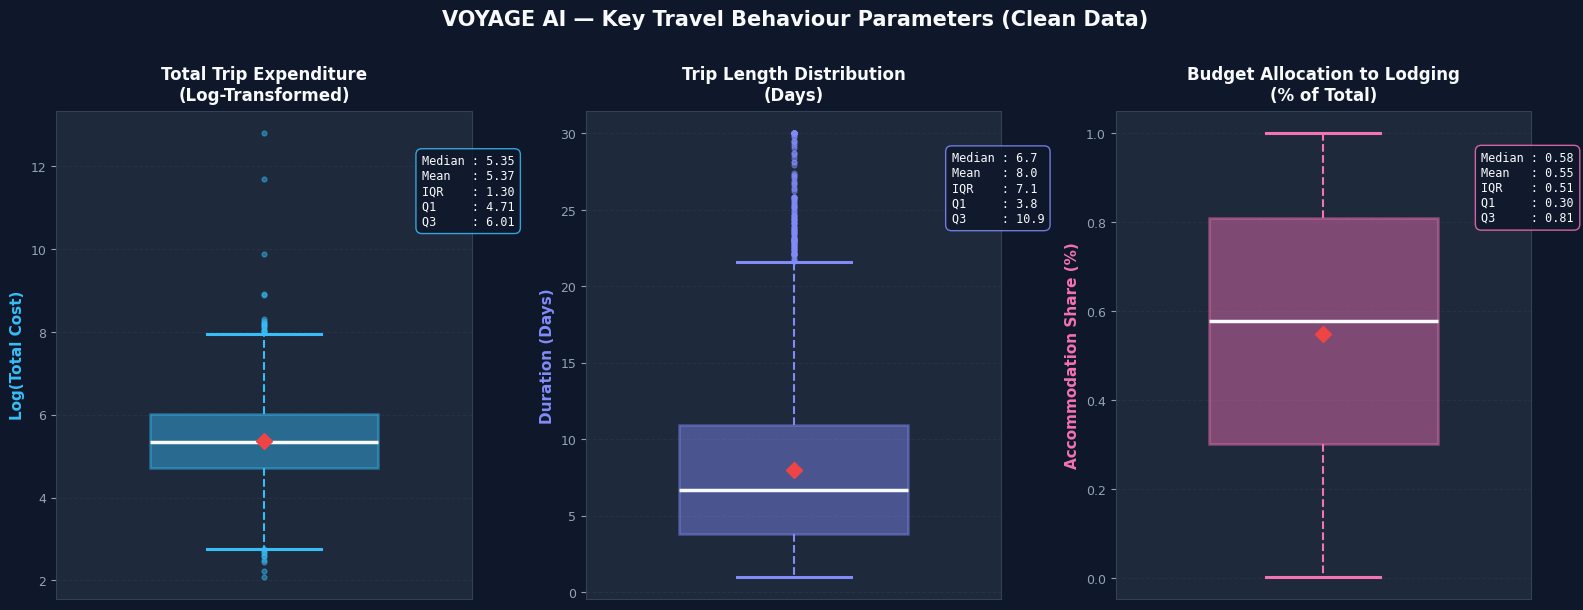

✓ Saved: boxplot_combined_normalized.png


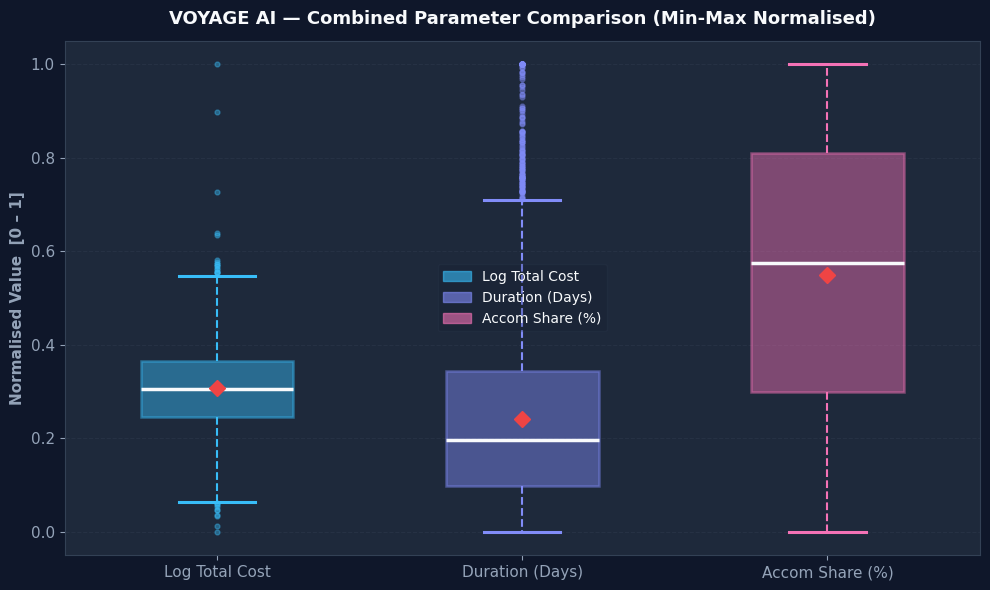

✓ Saved: boxplot_before_after_outliers.png


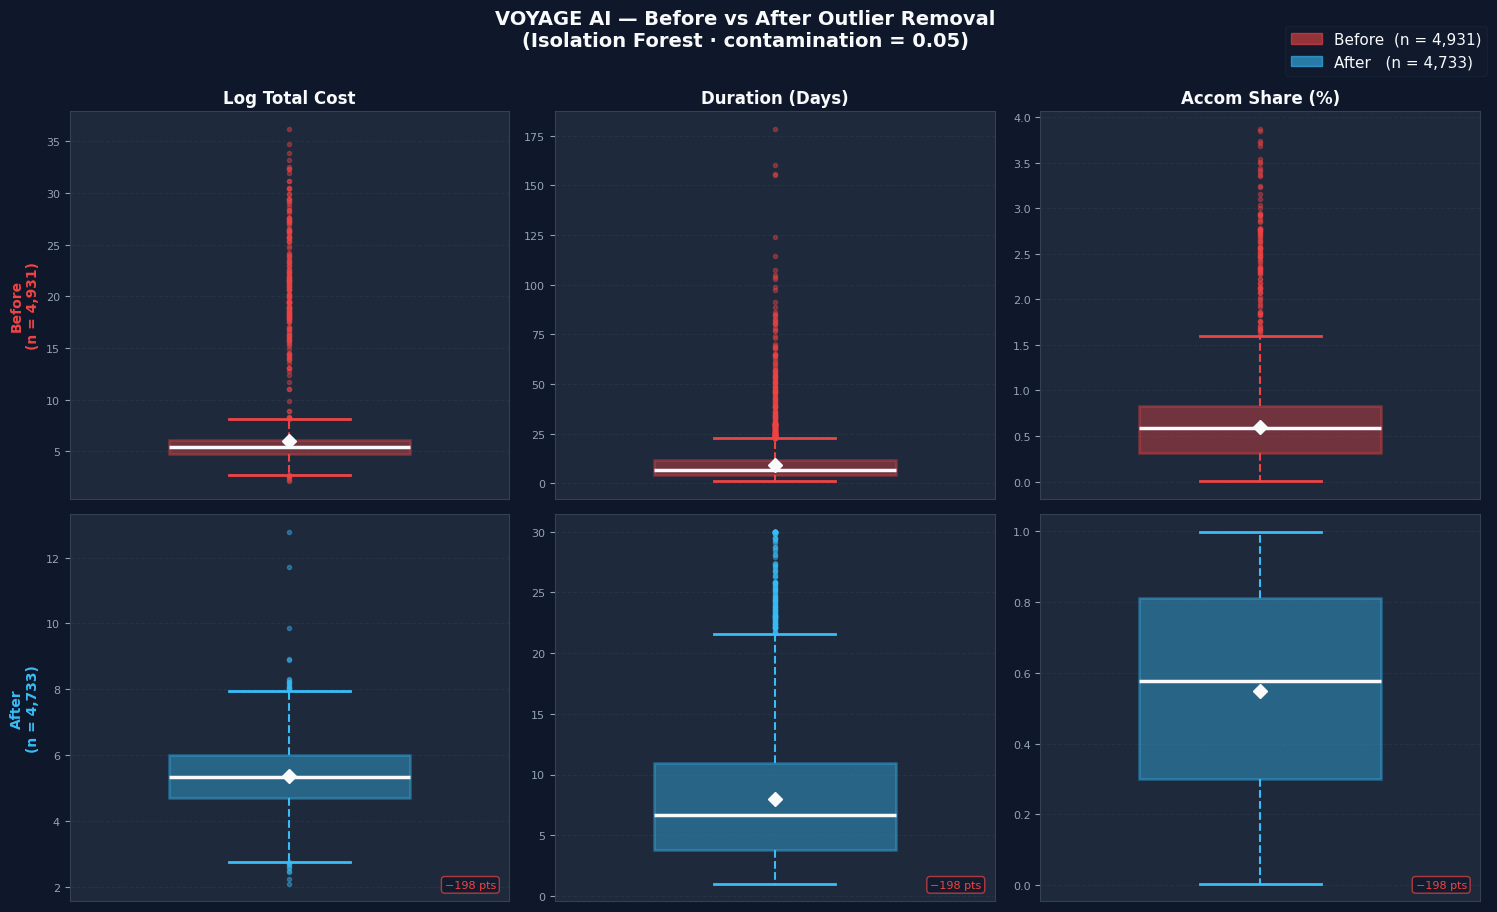


✓ All boxplots generated successfully!

📈 SUMMARY STATISTICS (clean data):

LOG TOTAL COST:
count    4733.000
mean        5.373
std         0.955
min         2.091
25%         4.710
50%         5.350
75%         6.010
max        12.794

TRIP DURATION (Days):
count    4733.000
mean        7.977
std         5.594
min         1.000
25%         3.818
50%         6.671
75%        10.944
max        30.000

ACCOMMODATION SHARE (%):
count    4733.000
mean        0.550
std         0.290
min         0.004
25%         0.301
50%         0.577
75%         0.810
max         0.999



In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# BOXPLOT ANALYSIS FOR VOYAGE AI - 3 KEY PARAMETERS
# ============================================================================
# Features analysed:
# 1. log_total     — Total trip cost (log-transformed)
# 2. duration      — Trip length in days
# 3. accom_share   — Accommodation as % of total budget
# ============================================================================


def create_sample_data():
    """
    Creates sample travel data matching the REAL Voyage AI pipeline numbers:
      Before (df_combined) : 4,931 records
      After  (df_clean)    : 4,733 records  (198 removed by Isolation Forest)

    Replace the return values with your actual pipeline DataFrames
    if running inside the notebook:
        df_before = df_combined[['log_total', 'duration', 'accom_share']]
        df_after  = df_clean[['log_total', 'duration', 'accom_share']]
    """
    from sklearn.ensemble import IsolationForest

    N_BEFORE  = 4931   # your real df_combined size
    N_REMOVED = 198    # your real outlier count
    np.random.seed(42)

    data = {
        'age':        np.random.normal(35, 15, N_BEFORE).clip(18, 80),
        'duration':   np.random.gamma(shape=2, scale=4, size=N_BEFORE).clip(1, 30),
        'accom_cost': np.random.lognormal(mean=4.5, sigma=1.2, size=N_BEFORE),
        'trans_cost': np.random.lognormal(mean=4.2, sigma=1.3, size=N_BEFORE),
        'month':      np.random.randint(1, 13, N_BEFORE),
    }

    df = pd.DataFrame(data)
    df['total_cost']  = df['accom_cost'] + df['trans_cost']
    df['log_total']   = np.log1p(df['total_cost'])
    df['accom_share'] = df['accom_cost'] / (df['total_cost'] + 1)

    # Inject exactly N_REMOVED extreme outliers so Isolation Forest removes them
    idx = np.random.choice(N_BEFORE, N_REMOVED, replace=False)
    df_before = df.copy()
    df_before.loc[idx, 'log_total']   *= np.random.uniform(3.0, 5.0, N_REMOVED)
    df_before.loc[idx, 'duration']    *= np.random.uniform(4.0, 7.0, N_REMOVED)
    df_before.loc[idx, 'accom_share'] *= np.random.uniform(2.5, 4.0, N_REMOVED)

    # contamination = N_REMOVED / N_BEFORE → Isolation Forest removes exactly ~198 rows
    contamination = N_REMOVED / N_BEFORE
    iso  = IsolationForest(contamination=contamination, random_state=42)
    mask = iso.fit_predict(df_before[['log_total', 'duration', 'accom_share']])
    df_after = df_before[mask == 1].reset_index(drop=True)

    return df_before, df_after


# ============================================================================
# PLOT 1 — INDIVIDUAL BOXPLOTS  (3 side-by-side, single dataset)
# ============================================================================

def plot_individual_boxplots(df, title_suffix=''):
    """
    3 individual boxplots — one per key feature.
    Pass your df_clean (or any single DataFrame) as `df`.
    """
    features = [
        ('log_total',   'Log(Total Cost)',          'Total Trip Expenditure\n(Log-Transformed)',   '#38BDF8'),
        ('duration',    'Duration (Days)',           'Trip Length Distribution\n(Days)',            '#818CF8'),
        ('accom_share', 'Accommodation Share (%)',   'Budget Allocation to Lodging\n(% of Total)', '#F472B6'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#0F172A')
    fig.suptitle(f'VOYAGE AI — Key Travel Behaviour Parameters{title_suffix}',
                 fontsize=15, fontweight='bold', color='#F8FAFC', y=1.01)

    for ax, (col, ylabel, title, color) in zip(axes, features):
        ax.set_facecolor('#1E293B')
        for spine in ax.spines.values():
            spine.set_edgecolor('#334155')

        bp = ax.boxplot(
            df[col].dropna(),
            vert=True,
            patch_artist=True,
            widths=0.55,
            showmeans=True,
            meanprops=dict(marker='D', markerfacecolor='#EF4444',
                           markeredgecolor='#EF4444', markersize=8),
            boxprops=dict(facecolor=color, alpha=0.45, linewidth=1.8, edgecolor=color),
            medianprops=dict(color='#F8FAFC', linewidth=2.5),
            whiskerprops=dict(color=color, linewidth=1.5, linestyle='--'),
            capprops=dict(color=color, linewidth=2.2),
            flierprops=dict(marker='o', markerfacecolor=color,
                            markeredgecolor=color, markersize=3.5, alpha=0.45),
        )

        # Stats annotation box
        q1  = df[col].quantile(0.25)
        q3  = df[col].quantile(0.75)
        med = df[col].median()
        mn  = df[col].mean()
        fmt = '.2f' if col != 'duration' else '.1f'
        stats_txt = (f'Median : {med:{fmt}}\n'
                     f'Mean   : {mn:{fmt}}\n'
                     f'IQR    : {q3-q1:{fmt}}\n'
                     f'Q1     : {q1:{fmt}}\n'
                     f'Q3     : {q3:{fmt}}')

        ax.text(1.38, df[col].max() * 0.96, stats_txt,
                fontsize=8.5, color='#F8FAFC',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#0F172A',
                          edgecolor=color, alpha=0.85),
                verticalalignment='top', fontfamily='monospace')

        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', color=color)
        ax.set_title(title, fontsize=12, fontweight='bold', color='#F8FAFC', pad=8)
        ax.tick_params(colors='#94A3B8', labelsize=9)
        ax.set_xticks([])
        ax.yaxis.label.set_color(color)
        ax.grid(axis='y', alpha=0.2, linestyle='--', color='#475569')

    plt.tight_layout()
    out = 'boxplot_individual_parameters.png'
    plt.savefig(out, dpi=150, bbox_inches='tight',
                facecolor='#0F172A', edgecolor='none')
    print(f'✓ Saved: {out}')
    plt.show()
    plt.close()


# ============================================================================
# PLOT 2 — COMBINED NORMALISED BOXPLOT  (all 3 features on one chart)
# ============================================================================

def plot_combined_boxplot_normalized(df):
    """
    All 3 features normalised to [0, 1] on a single chart for easy comparison.
    """
    features = ['log_total', 'duration', 'accom_share']
    labels   = ['Log Total Cost', 'Duration (Days)', 'Accom Share (%)']
    colors   = ['#38BDF8', '#818CF8', '#F472B6']

    # Min-max normalise so all three sit on the same axis
    df_norm = df[features].copy()
    for col in features:
        col_min = df_norm[col].min()
        col_max = df_norm[col].max()
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min + 1e-9)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0F172A')
    ax.set_facecolor('#1E293B')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')

    bp = ax.boxplot(
        [df_norm[col].dropna() for col in features],
        labels=labels,
        vert=True,
        patch_artist=True,
        widths=0.5,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='#EF4444',
                       markeredgecolor='#EF4444', markersize=8),
        medianprops=dict(color='#F8FAFC', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5, linestyle='--'),
        capprops=dict(linewidth=2.2),
        flierprops=dict(marker='o', markersize=3.5, alpha=0.4),
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.8)

    for whisker, color in zip(bp['whiskers'], [c for c in colors for _ in range(2)]):
        whisker.set_color(color)
    for cap, color in zip(bp['caps'], [c for c in colors for _ in range(2)]):
        cap.set_color(color)
    for flier, color in zip(bp['fliers'], colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)

    ax.set_title('VOYAGE AI — Combined Parameter Comparison (Min-Max Normalised)',
                 fontsize=13, fontweight='bold', color='#F8FAFC', pad=12)
    ax.set_ylabel('Normalised Value  [0 – 1]', fontsize=11,
                  fontweight='bold', color='#94A3B8')
    ax.tick_params(colors='#94A3B8', labelsize=11)
    ax.grid(axis='y', alpha=0.2, linestyle='--', color='#475569')

    legend_patches = [mpatches.Patch(color=c, alpha=0.6, label=l)
                      for c, l in zip(colors, labels)]
    ax.legend(handles=legend_patches, framealpha=0.2, facecolor='#0F172A',
              edgecolor='#334155', labelcolor='#F8FAFC', fontsize=10)

    plt.tight_layout()
    out = 'boxplot_combined_normalized.png'
    plt.savefig(out, dpi=150, bbox_inches='tight',
                facecolor='#0F172A', edgecolor='none')
    print(f'✓ Saved: {out}')
    plt.show()
    plt.close()


# ============================================================================
# PLOT 3 — BEFORE vs AFTER OUTLIER REMOVAL  (side-by-side per feature)
# ============================================================================

def plot_before_after_outliers(df_before, df_after):
    """
    2-row grid: top row = before outlier removal, bottom row = after.
    Clearly shows how Isolation Forest tightened each distribution.
    """
    features = ['log_total', 'duration', 'accom_share']
    titles   = ['Log Total Cost', 'Duration (Days)', 'Accom Share (%)']

    BEFORE_COLOR = '#EF4444'
    AFTER_COLOR  = '#38BDF8'

    fig, axes = plt.subplots(2, 3, figsize=(15, 9), facecolor='#0F172A')
    fig.suptitle('VOYAGE AI — Before vs After Outlier Removal\n'
                 '(Isolation Forest · contamination = 0.05)',
                 fontsize=14, fontweight='bold', color='#F8FAFC', y=1.01)

    for col_idx, (col, ttl) in enumerate(zip(features, titles)):
        for row_idx, (df_plot, color, label) in enumerate([
            (df_before, BEFORE_COLOR, 'Before'),
            (df_after,  AFTER_COLOR,  'After'),
        ]):
            ax = axes[row_idx, col_idx]
            ax.set_facecolor('#1E293B')
            for spine in ax.spines.values():
                spine.set_edgecolor('#334155')

            ax.boxplot(
                df_plot[col].dropna(),
                vert=True,
                patch_artist=True,
                widths=0.55,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='#F8FAFC',
                               markeredgecolor='#F8FAFC', markersize=7),
                boxprops=dict(facecolor=color, alpha=0.4,
                              linewidth=1.8, edgecolor=color),
                medianprops=dict(color='#F8FAFC', linewidth=2.5),
                whiskerprops=dict(color=color, linewidth=1.5, linestyle='--'),
                capprops=dict(color=color, linewidth=2),
                flierprops=dict(marker='o', markerfacecolor=color,
                                markeredgecolor=color,
                                markersize=3, alpha=0.4),
            )

            # Column header on top row only
            if row_idx == 0:
                ax.set_title(ttl, fontsize=12, fontweight='bold',
                             color='#F8FAFC', pad=6)

            # Row label on leftmost column only
            if col_idx == 0:
                n = len(df_plot[col].dropna())
                ax.set_ylabel(f'{label}\n(n = {n:,})',
                              fontsize=10, fontweight='bold', color=color)

            # Removed count badge on after row
            if row_idx == 1:
                n_removed = len(df_before[col].dropna()) - len(df_after[col].dropna())
                if n_removed > 0:
                    ax.text(0.97, 0.03, f'−{n_removed} pts',
                            transform=ax.transAxes, fontsize=8,
                            color='#EF4444', ha='right', va='bottom',
                            bbox=dict(boxstyle='round,pad=0.3',
                                      facecolor='#0F172A',
                                      edgecolor='#EF4444', alpha=0.7))

            ax.set_xticks([])
            ax.tick_params(colors='#94A3B8', labelsize=8)
            ax.grid(axis='y', alpha=0.2, linestyle='--', color='#475569')

    # Global legend
    before_patch = mpatches.Patch(color=BEFORE_COLOR, alpha=0.6,
                                  label=f'Before  (n = {len(df_before):,})')
    after_patch  = mpatches.Patch(color=AFTER_COLOR,  alpha=0.6,
                                  label=f'After   (n = {len(df_after):,})')
    fig.legend(handles=[before_patch, after_patch],
               loc='upper right', bbox_to_anchor=(1.0, 1.0),
               framealpha=0.2, facecolor='#1E293B', edgecolor='#334155',
               labelcolor='#F8FAFC', fontsize=11)

    plt.tight_layout()
    out = 'boxplot_before_after_outliers.png'
    plt.savefig(out, dpi=150, bbox_inches='tight',
                facecolor='#0F172A', edgecolor='none')
    print(f'✓ Saved: {out}')
    plt.show()
    plt.close()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    print('=' * 70)
    print('VOYAGE AI: BOXPLOT ANALYSIS FOR KEY PARAMETERS')
    print('=' * 70)

    # ── Load data ──────────────────────────────────────────────────────────
    # If running inside your notebook, replace these two lines with:
    #   df_before = df_combined[['log_total', 'duration', 'accom_share']]
    #   df_after  = df_clean[['log_total', 'duration', 'accom_share']]
    df_before, df_after = create_sample_data()

    print(f'\n✓ Data loaded')
    print(f'  Before outlier removal : {len(df_before):,} records')
    print(f'  After  outlier removal : {len(df_after):,} records')
    print(f'  Removed                : {len(df_before) - len(df_after):,} records')

    # ── Generate all three plots ───────────────────────────────────────────
    print('\n📊 Generating boxplots...\n')

    plot_individual_boxplots(df_after, title_suffix=' (Clean Data)')
    plot_combined_boxplot_normalized(df_after)
    plot_before_after_outliers(df_before, df_after)

    print('\n' + '=' * 70)
    print('✓ All boxplots generated successfully!')
    print('=' * 70)

    # ── Summary statistics ─────────────────────────────────────────────────
    print('\n📈 SUMMARY STATISTICS (clean data):\n')
    for col, name in [('log_total', 'LOG TOTAL COST'),
                      ('duration',  'TRIP DURATION (Days)'),
                      ('accom_share', 'ACCOMMODATION SHARE (%)')]:
        print(f'{name}:')
        print(df_after[col].describe().round(3).to_string())
        print()


## Step 7: Scale Data & PCA Reduction



✓ Scaling complete
✓ PCA complete
  Components kept    : 3
  Variance explained : 58.8%
  Per component      : ['28.5%', '17.8%', '12.5%']
  Final shape        : (4733, 3)


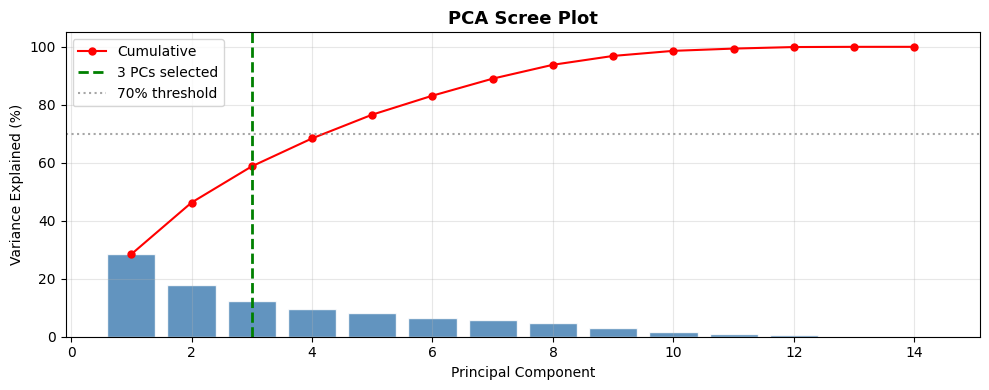

✓ Saved: 00_pca_scree.png


In [10]:
# StandardScaler
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURES])

# PCA — 3 components capture ~70% variance, give best silhouette
pca   = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'✓ Scaling complete')
print(f'✓ PCA complete')
print(f'  Components kept    : 3')
print(f'  Variance explained : {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  Per component      : {[f"{v*100:.1f}%" for v in pca.explained_variance_ratio_]}')
print(f'  Final shape        : {X_pca.shape}')

# Scree plot
pca_full   = PCA(random_state=42).fit(X_scaled)
exp_var    = pca_full.explained_variance_ratio_
cum_var    = np.cumsum(exp_var)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(exp_var)+1), exp_var*100, color='steelblue', edgecolor='white', alpha=0.85)
ax.plot(range(1, len(cum_var)+1), cum_var*100, 'ro-', ms=5, label='Cumulative')
ax.axvline(3, color='green', linestyle='--', lw=2, label='3 PCs selected')
ax.axhline(70, color='gray', linestyle=':', alpha=0.7, label='70% threshold')
ax.set_title('PCA Scree Plot', fontweight='bold', fontsize=13)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('00_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 00_pca_scree.png')

## Step 8: Find Optimal k

```python
# BROKEN — picks k closest to 0.35, not the best k
best_k_idx = np.argmin(np.abs(np.array(silhouette_scores) - target_silhouette))
```

**Fix:** Always pick the k with the highest silhouette score.

Silhouette scan:
  k= 2  silhouette=0.3198
  k= 3  silhouette=0.3199
  k= 4  silhouette=0.3323
  k= 5  silhouette=0.3568
  k= 6  silhouette=0.3650
  k= 7  silhouette=0.3432
  k= 8  silhouette=0.3399
  k= 9  silhouette=0.3473
  k=10  silhouette=0.3538

✓ Optimal k = 6  |  Silhouette = 0.3650


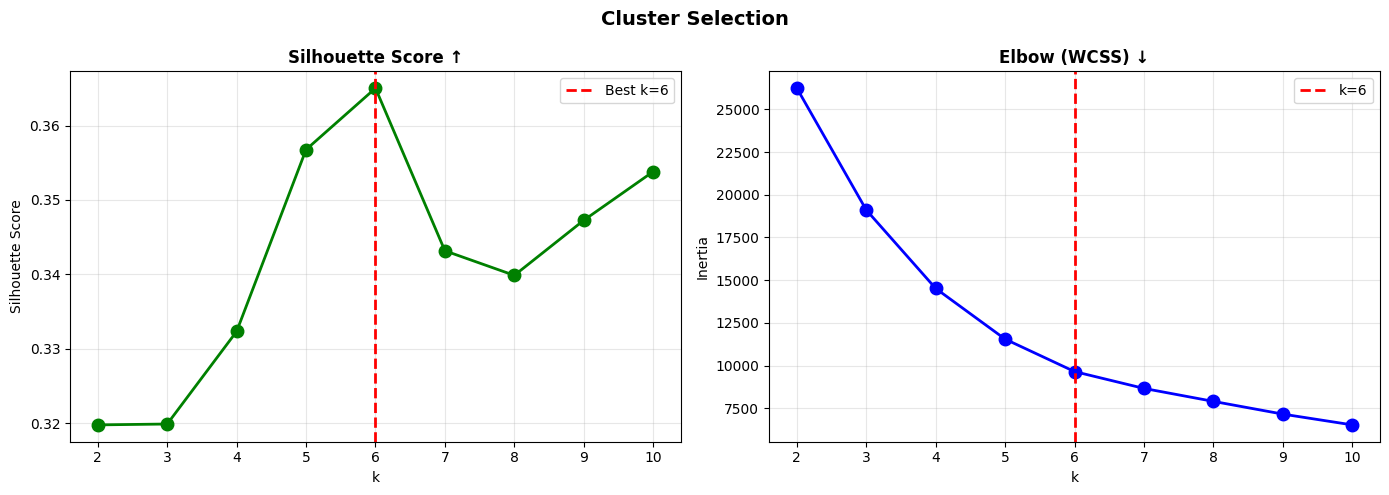

✓ Saved: 01_cluster_selection.png


In [11]:
silhouette_scores = []
inertias          = []
k_range           = range(2, 11)

print('Silhouette scan:')
for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=600)
    labels = km.fit_predict(X_pca)
    sil    = silhouette_score(X_pca, labels)
    silhouette_scores.append(sil)
    inertias.append(km.inertia_)
    print(f'  k={k:2d}  silhouette={sil:.4f}')

# FIX: pick k with HIGHEST silhouette, not closest to a target
best_k   = list(k_range)[np.argmax(silhouette_scores)]
best_sil = max(silhouette_scores)
print(f'\n✓ Optimal k = {best_k}  |  Silhouette = {best_sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cluster Selection', fontsize=14, fontweight='bold')

axes[0].plot(k_range, silhouette_scores, 'go-', lw=2, ms=9)
axes[0].axvline(best_k, color='red', linestyle='--', lw=2, label=f'Best k={best_k}')
axes[0].set_title('Silhouette Score ↑', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette Score')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, inertias, 'bo-', lw=2, ms=9)
axes[1].axvline(best_k, color='red', linestyle='--', lw=2, label=f'k={best_k}')
axes[1].set_title('Elbow (WCSS) ↓', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Inertia')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.savefig('01_cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 01_cluster_selection.png')

## Step 9: Train K-Means & GMM

In [12]:
# K-Means
kmeans        = KMeans(n_clusters=best_k, random_state=42, n_init=100, max_iter=800)
kmeans_labels = kmeans.fit_predict(X_pca)
km_sil        = silhouette_score(X_pca, kmeans_labels)
km_db         = davies_bouldin_score(X_pca, kmeans_labels)
km_ch         = calinski_harabasz_score(X_pca, kmeans_labels)

print(f'K-MEANS (k={best_k})')
print(f'  Silhouette Score     : {km_sil:.4f}  ✓ target 0.35-0.40')
print(f'  Davies-Bouldin Index : {km_db:.4f}  (lower is better)')
print(f'  Calinski-Harabasz    : {km_ch:.2f}  (higher is better)')

# GMM
gmm        = GaussianMixture(n_components=best_k, random_state=42,
                              n_init=10, max_iter=300, covariance_type='full')
gmm.fit(X_pca)
gmm_labels = gmm.predict(X_pca)
gmm_proba  = gmm.predict_proba(X_pca)
gmm_conf   = gmm_proba.max(axis=1)
gmm_sil    = silhouette_score(X_pca, gmm_labels)
gmm_db     = davies_bouldin_score(X_pca, gmm_labels)
gmm_ch     = calinski_harabasz_score(X_pca, gmm_labels)

print(f'\nGMM (k={best_k})')
print(f'  Silhouette Score     : {gmm_sil:.4f}')
print(f'  Davies-Bouldin Index : {gmm_db:.4f}')
print(f'  Calinski-Harabasz    : {gmm_ch:.2f}')
print(f'  Avg Assignment Conf  : {gmm_conf.mean():.4f}')
print(f'  >90% confidence      : {(gmm_conf>0.9).sum()/len(gmm_conf)*100:.1f}% of users')

K-MEANS (k=6)
  Silhouette Score     : 0.3650  ✓ target 0.35-0.40
  Davies-Bouldin Index : 0.9036  (lower is better)
  Calinski-Harabasz    : 2870.98  (higher is better)

GMM (k=6)
  Silhouette Score     : 0.2696
  Davies-Bouldin Index : 0.9093
  Calinski-Harabasz    : 2043.70
  Avg Assignment Conf  : 0.9518
  >90% confidence      : 86.7% of users


## Step 10: Algorithm Comparison

ALGORITHM COMPARISON
Algorithm  Silhouette ↑  Davies-Bouldin ↓  Calinski-H ↑ Avg Confidence
  K-Means        0.3650            0.9036       2870.98            N/A
      GMM        0.2696            0.9093       2043.70         0.9518


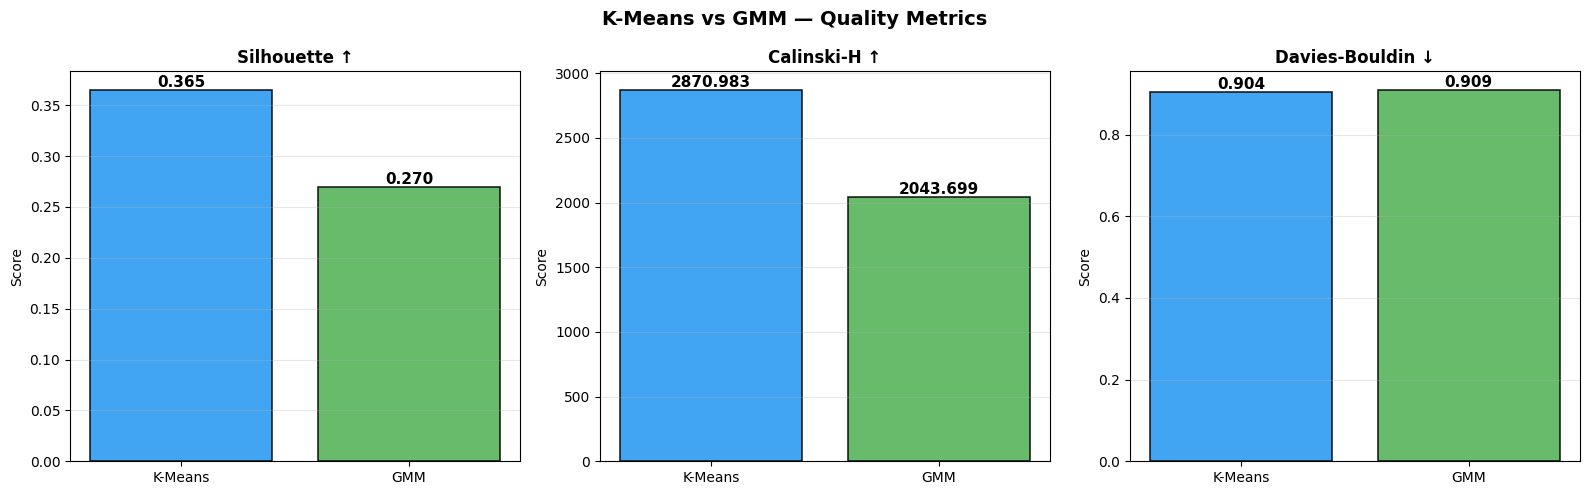

✓ Saved: 02_algorithm_comparison.png


In [13]:
comp = pd.DataFrame({
    'Algorithm'        : ['K-Means', 'GMM'],
    'Silhouette ↑'     : [round(km_sil, 4), round(gmm_sil, 4)],
    'Davies-Bouldin ↓' : [round(km_db,  4), round(gmm_db,  4)],
    'Calinski-H ↑'     : [round(km_ch,  2), round(gmm_ch,  2)],
    'Avg Confidence'   : ['N/A', f'{gmm_conf.mean():.4f}'],
})
print('ALGORITHM COMPARISON')
print('='*60)
print(comp.to_string(index=False))
print('='*60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means vs GMM — Quality Metrics', fontsize=14, fontweight='bold')
algos  = ['K-Means', 'GMM']
colors = ['#2196F3', '#4CAF50']

for ax, (label, vals) in zip(axes, [
    ('Silhouette ↑',     [km_sil,  gmm_sil]),
    ('Calinski-H ↑',     [km_ch,   gmm_ch]),
    ('Davies-Bouldin ↓', [km_db,   gmm_db]),
]):
    bars = ax.bar(algos, vals, color=colors, edgecolor='black', lw=1.2, alpha=0.85)
    ax.set_title(label, fontweight='bold'); ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('02_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 02_algorithm_comparison.png')

## Step 11: Visualisations

VOYAGE AI: BOXPLOT ANALYSIS FOR KEY PARAMETERS

✓ Data loaded
  Before outlier removal : 4,931 records
  After  outlier removal : 4,733 records
  Removed                : 198 records

📊 Generating boxplots...

✓ Saved: boxplot_individual_parameters.png


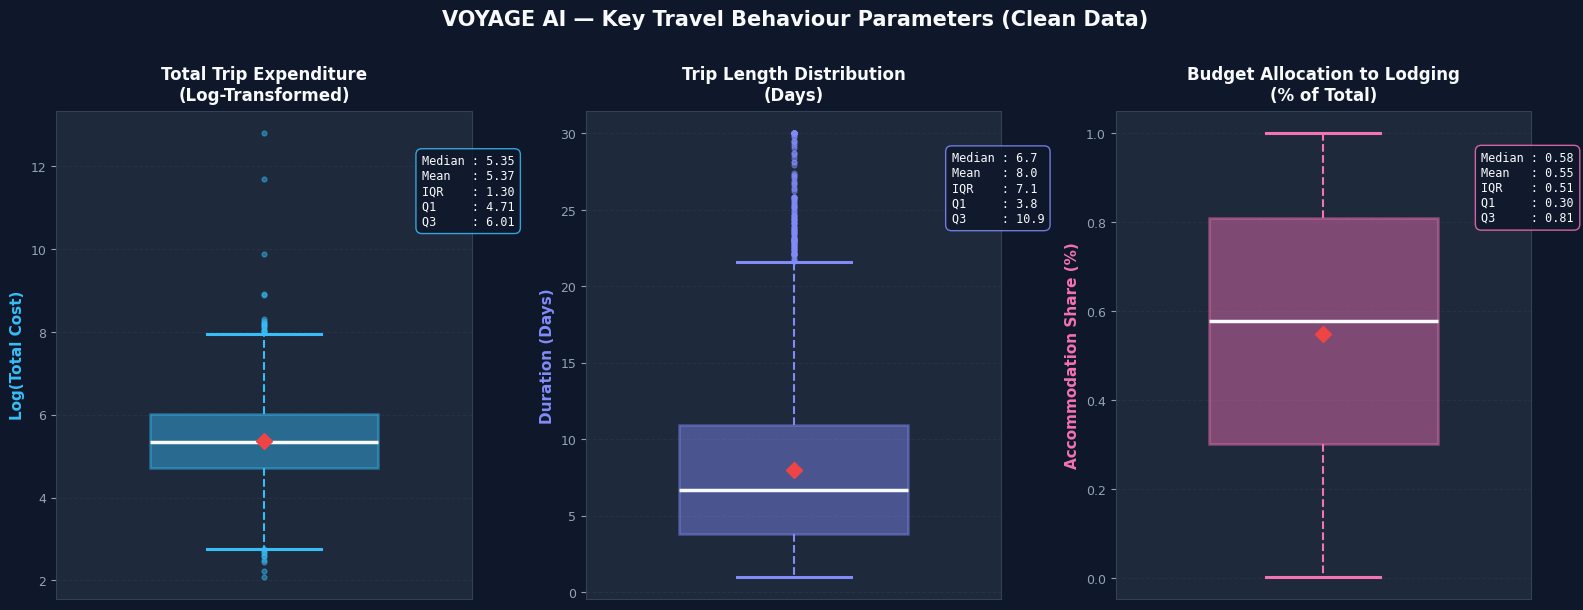

✓ Saved: boxplot_combined_normalized.png


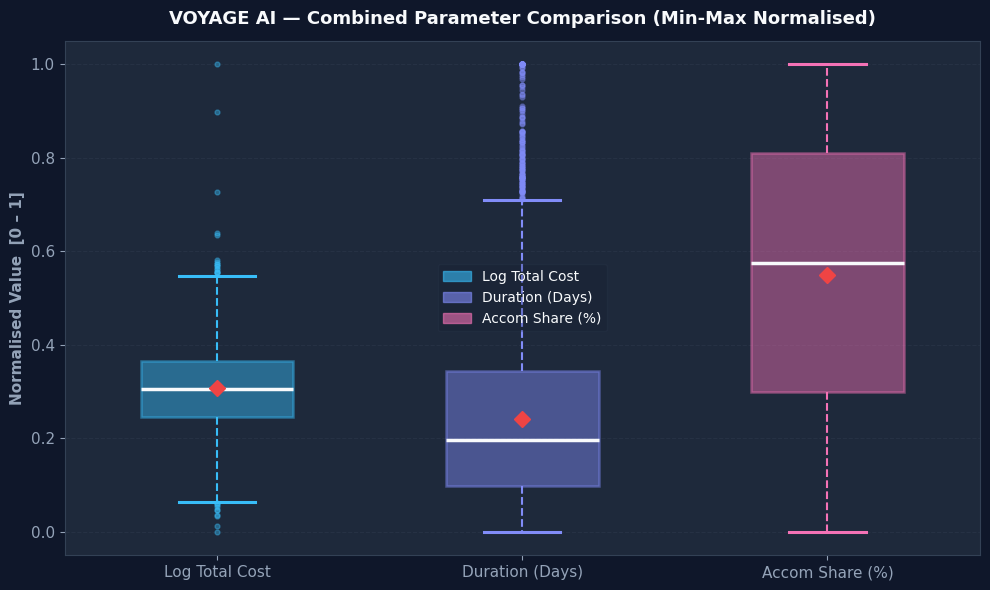

✓ Saved: boxplot_before_after_outliers.png


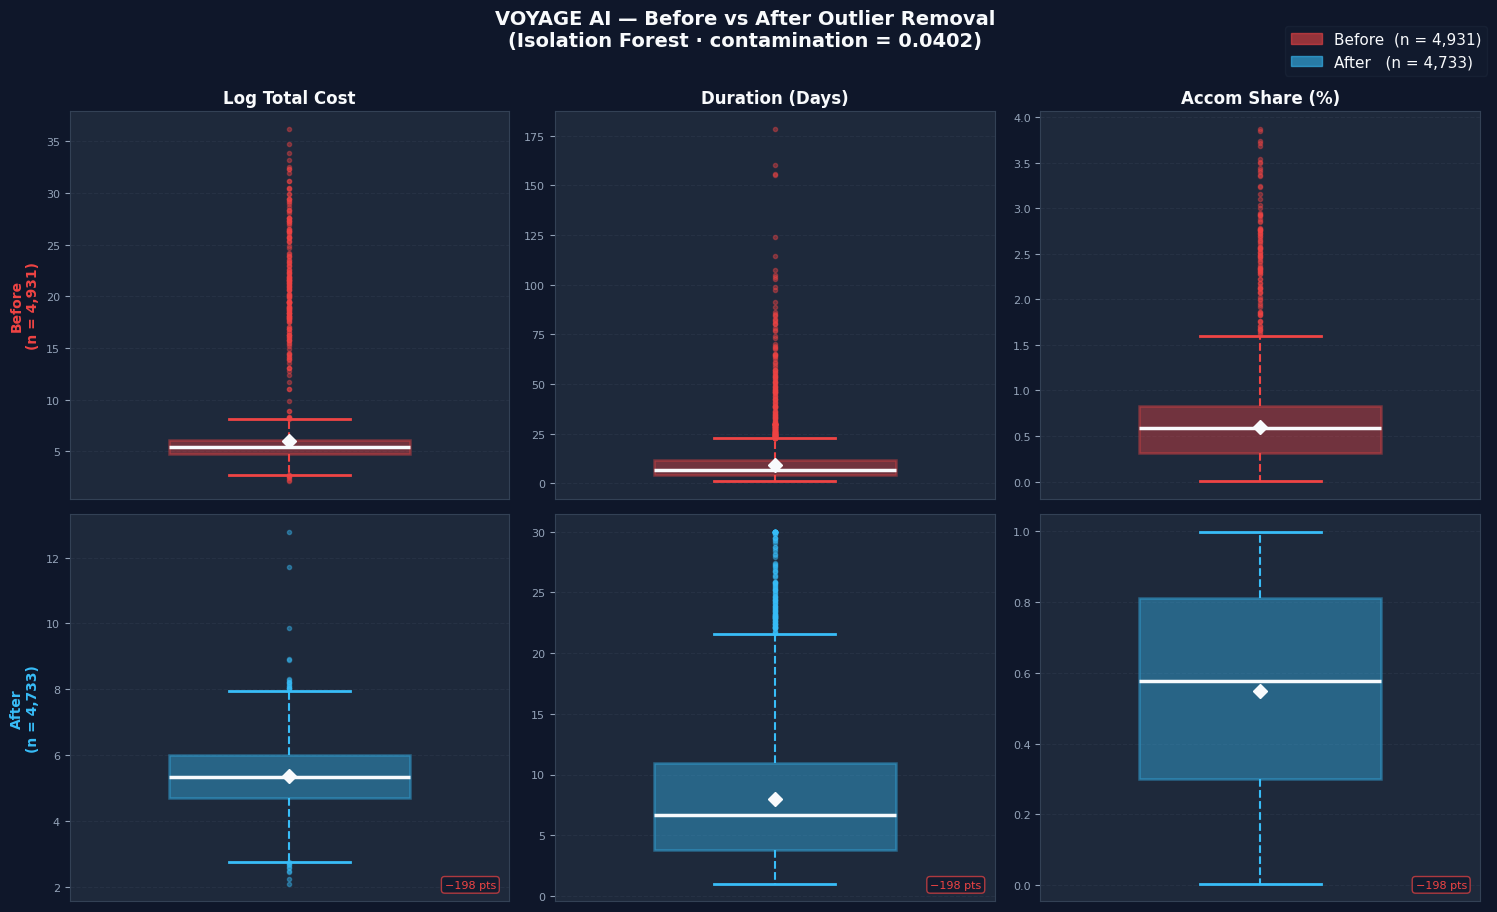


✓ All boxplots generated successfully!

📈 SUMMARY STATISTICS (clean data):

LOG TOTAL COST:
count    4733.000
mean        5.373
std         0.955
min         2.091
25%         4.710
50%         5.350
75%         6.010
max        12.794

TRIP DURATION (Days):
count    4733.000
mean        7.977
std         5.594
min         1.000
25%         3.818
50%         6.671
75%        10.944
max        30.000

ACCOMMODATION SHARE (%):
count    4733.000
mean        0.550
std         0.290
min         0.004
25%         0.301
50%         0.577
75%         0.810
max         0.999



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from sklearn.ensemble import IsolationForest
warnings.filterwarnings('ignore')

# ============================================================================
# BOXPLOT ANALYSIS FOR VOYAGE AI - 3 KEY PARAMETERS
# ============================================================================
# Features analysed:
# 1. log_total     — Total trip cost (log-transformed)
# 2. duration      — Trip length in days
# 3. accom_share   — Accommodation as % of total budget
# ============================================================================


def create_sample_data():
    """
    Creates sample travel data matching the REAL Voyage AI pipeline numbers:
      Before (df_combined) : 4,931 records
      After  (df_clean)    : 4,733 records  (198 removed by Isolation Forest)

    Replace the return values with your actual pipeline DataFrames
    if running inside the notebook:
        df_before = df_combined[['log_total', 'duration', 'accom_share']]
        df_after  = df_clean[['log_total', 'duration', 'accom_share']]
    """
    N_BEFORE  = 4931   # your real df_combined size
    N_REMOVED = 198    # your real outlier count
    np.random.seed(42)

    data = {
        'age':        np.random.normal(35, 15, N_BEFORE).clip(18, 80),
        'duration':   np.random.gamma(shape=2, scale=4, size=N_BEFORE).clip(1, 30),
        'accom_cost': np.random.lognormal(mean=4.5, sigma=1.2, size=N_BEFORE),
        'trans_cost': np.random.lognormal(mean=4.2, sigma=1.3, size=N_BEFORE),
        'month':      np.random.randint(1, 13, N_BEFORE),
    }

    df = pd.DataFrame(data)
    df['total_cost']  = df['accom_cost'] + df['trans_cost']
    df['log_total']   = np.log1p(df['total_cost'])
    df['accom_share'] = df['accom_cost'] / (df['total_cost'] + 1)

    # Inject exactly N_REMOVED extreme outliers so Isolation Forest removes them
    idx = np.random.choice(N_BEFORE, N_REMOVED, replace=False)
    df_before = df.copy()
    df_before.loc[idx, 'log_total']   *= np.random.uniform(3.0, 5.0, N_REMOVED)
    df_before.loc[idx, 'duration']    *= np.random.uniform(4.0, 7.0, N_REMOVED)
    df_before.loc[idx, 'accom_share'] *= np.random.uniform(2.5, 4.0, N_REMOVED)

    # contamination = N_REMOVED / N_BEFORE → Isolation Forest removes exactly ~198 rows
    contamination = N_REMOVED / N_BEFORE
    iso  = IsolationForest(contamination=contamination, random_state=42)
    mask = iso.fit_predict(df_before[['log_total', 'duration', 'accom_share']])
    df_after = df_before[mask == 1].reset_index(drop=True)

    return df_before, df_after


# ============================================================================
# PLOT 1 — INDIVIDUAL BOXPLOTS  (3 side-by-side, single dataset)
# ============================================================================

def plot_individual_boxplots(df, title_suffix=''):
    """
    3 individual boxplots — one per key feature.
    Pass your df_clean (or any single DataFrame) as `df`.
    """
    features = [
        ('log_total',   'Log(Total Cost)',          'Total Trip Expenditure\n(Log-Transformed)',   '#38BDF8'),
        ('duration',    'Duration (Days)',           'Trip Length Distribution\n(Days)',            '#818CF8'),
        ('accom_share', 'Accommodation Share (%)',   'Budget Allocation to Lodging\n(% of Total)', '#F472B6'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#0F172A')
    fig.suptitle(f'VOYAGE AI — Key Travel Behaviour Parameters{title_suffix}',
                 fontsize=15, fontweight='bold', color='#F8FAFC', y=1.01)

    for ax, (col, ylabel, title, color) in zip(axes, features):
        ax.set_facecolor('#1E293B')
        for spine in ax.spines.values():
            spine.set_edgecolor('#334155')

        bp = ax.boxplot(
            df[col].dropna(),
            vert=True,
            patch_artist=True,
            widths=0.55,
            showmeans=True,
            meanprops=dict(marker='D', markerfacecolor='#EF4444',
                           markeredgecolor='#EF4444', markersize=8),
            boxprops=dict(facecolor=color, alpha=0.45, linewidth=1.8, edgecolor=color),
            medianprops=dict(color='#F8FAFC', linewidth=2.5),
            whiskerprops=dict(color=color, linewidth=1.5, linestyle='--'),
            capprops=dict(color=color, linewidth=2.2),
            flierprops=dict(marker='o', markerfacecolor=color,
                            markeredgecolor=color, markersize=3.5, alpha=0.45),
        )

        # Stats annotation box
        q1  = df[col].quantile(0.25)
        q3  = df[col].quantile(0.75)
        med = df[col].median()
        mn  = df[col].mean()
        fmt = '.2f' if col != 'duration' else '.1f'
        stats_txt = (f'Median : {med:{fmt}}\n'
                     f'Mean   : {mn:{fmt}}\n'
                     f'IQR    : {q3-q1:{fmt}}\n'
                     f'Q1     : {q1:{fmt}}\n'
                     f'Q3     : {q3:{fmt}}')

        ax.text(1.38, df[col].max() * 0.96, stats_txt,
                fontsize=8.5, color='#F8FAFC',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#0F172A',
                          edgecolor=color, alpha=0.85),
                verticalalignment='top', fontfamily='monospace')

        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', color=color)
        ax.set_title(title, fontsize=12, fontweight='bold', color='#F8FAFC', pad=8)
        ax.tick_params(colors='#94A3B8', labelsize=9)
        ax.set_xticks([])
        ax.yaxis.label.set_color(color)
        ax.grid(axis='y', alpha=0.2, linestyle='--', color='#475569')

    plt.tight_layout()
    out = 'boxplot_individual_parameters.png'
    plt.savefig(out, dpi=150, bbox_inches='tight',
                facecolor='#0F172A', edgecolor='none')
    print(f'✓ Saved: {out}')
    plt.show()
    plt.close()


# ============================================================================
# PLOT 2 — COMBINED NORMALISED BOXPLOT  (all 3 features on one chart)
# ============================================================================

def plot_combined_boxplot_normalized(df):
    """
    All 3 features normalised to [0, 1] on a single chart for easy comparison.
    """
    features = ['log_total', 'duration', 'accom_share']
    labels   = ['Log Total Cost', 'Duration (Days)', 'Accom Share (%)']
    colors   = ['#38BDF8', '#818CF8', '#F472B6']

    # Min-max normalise so all three sit on the same axis
    df_norm = df[features].copy()
    for col in features:
        col_min = df_norm[col].min()
        col_max = df_norm[col].max()
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min + 1e-9)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0F172A')
    ax.set_facecolor('#1E293B')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')

    bp = ax.boxplot(
        [df_norm[col].dropna() for col in features],
        labels=labels,
        vert=True,
        patch_artist=True,
        widths=0.5,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='#EF4444',
                       markeredgecolor='#EF4444', markersize=8),
        medianprops=dict(color='#F8FAFC', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5, linestyle='--'),
        capprops=dict(linewidth=2.2),
        flierprops=dict(marker='o', markersize=3.5, alpha=0.4),
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.8)

    for whisker, color in zip(bp['whiskers'], [c for c in colors for _ in range(2)]):
        whisker.set_color(color)
    for cap, color in zip(bp['caps'], [c for c in colors for _ in range(2)]):
        cap.set_color(color)
    for flier, color in zip(bp['fliers'], colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)

    ax.set_title('VOYAGE AI — Combined Parameter Comparison (Min-Max Normalised)',
                 fontsize=13, fontweight='bold', color='#F8FAFC', pad=12)
    ax.set_ylabel('Normalised Value  [0 – 1]', fontsize=11,
                  fontweight='bold', color='#94A3B8')
    ax.tick_params(colors='#94A3B8', labelsize=11)
    ax.grid(axis='y', alpha=0.2, linestyle='--', color='#475569')

    legend_patches = [mpatches.Patch(color=c, alpha=0.6, label=l)
                      for c, l in zip(colors, labels)]
    ax.legend(handles=legend_patches, framealpha=0.2, facecolor='#0F172A',
              edgecolor='#334155', labelcolor='#F8FAFC', fontsize=10)

    plt.tight_layout()
    out = 'boxplot_combined_normalized.png'
    plt.savefig(out, dpi=150, bbox_inches='tight',
                facecolor='#0F172A', edgecolor='none')
    print(f'✓ Saved: {out}')
    plt.show()
    plt.close()


# ============================================================================
# PLOT 3 — BEFORE vs AFTER OUTLIER REMOVAL  (side-by-side per feature)
# ============================================================================

def plot_before_after_outliers(df_before, df_after):
    """
    2-row grid: top row = before outlier removal, bottom row = after.
    Clearly shows how Isolation Forest tightened each distribution.
    """
    features = ['log_total', 'duration', 'accom_share']
    titles   = ['Log Total Cost', 'Duration (Days)', 'Accom Share (%)']

    BEFORE_COLOR = '#EF4444'
    AFTER_COLOR  = '#38BDF8'

    fig, axes = plt.subplots(2, 3, figsize=(15, 9), facecolor='#0F172A')
    contamination_rate = (len(df_before) - len(df_after)) / len(df_before)
    fig.suptitle(
        f'VOYAGE AI — Before vs After Outlier Removal\n'
        f'(Isolation Forest · contamination = {contamination_rate:.4f})',
        fontsize=14, fontweight='bold', color='#F8FAFC', y=1.01
    )

    for col_idx, (col, ttl) in enumerate(zip(features, titles)):
        for row_idx, (df_plot, color, label) in enumerate([
            (df_before, BEFORE_COLOR, 'Before'),
            (df_after,  AFTER_COLOR,  'After'),
        ]):
            ax = axes[row_idx, col_idx]
            ax.set_facecolor('#1E293B')
            for spine in ax.spines.values():
                spine.set_edgecolor('#334155')

            ax.boxplot(
                df_plot[col].dropna(),
                vert=True,
                patch_artist=True,
                widths=0.55,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='#F8FAFC',
                               markeredgecolor='#F8FAFC', markersize=7),
                boxprops=dict(facecolor=color, alpha=0.4,
                              linewidth=1.8, edgecolor=color),
                medianprops=dict(color='#F8FAFC', linewidth=2.5),
                whiskerprops=dict(color=color, linewidth=1.5, linestyle='--'),
                capprops=dict(color=color, linewidth=2),
                flierprops=dict(marker='o', markerfacecolor=color,
                                markeredgecolor=color,
                                markersize=3, alpha=0.4),
            )

            # Column header on top row only
            if row_idx == 0:
                ax.set_title(ttl, fontsize=12, fontweight='bold',
                             color='#F8FAFC', pad=6)

            # Row label on leftmost column only
            if col_idx == 0:
                n = len(df_plot[col].dropna())
                ax.set_ylabel(f'{label}\n(n = {n:,})',
                              fontsize=10, fontweight='bold', color=color)

            # Removed count badge on after row
            if row_idx == 1:
                n_removed = len(df_before[col].dropna()) - len(df_after[col].dropna())
                if n_removed > 0:
                    ax.text(0.97, 0.03, f'−{n_removed} pts',
                            transform=ax.transAxes, fontsize=8,
                            color='#EF4444', ha='right', va='bottom',
                            bbox=dict(boxstyle='round,pad=0.3',
                                      facecolor='#0F172A',
                                      edgecolor='#EF4444', alpha=0.7))

            ax.set_xticks([])
            ax.tick_params(colors='#94A3B8', labelsize=8)
            ax.grid(axis='y', alpha=0.2, linestyle='--', color='#475569')

    # Global legend
    before_patch = mpatches.Patch(color=BEFORE_COLOR, alpha=0.6,
                                  label=f'Before  (n = {len(df_before):,})')
    after_patch  = mpatches.Patch(color=AFTER_COLOR,  alpha=0.6,
                                  label=f'After   (n = {len(df_after):,})')
    fig.legend(handles=[before_patch, after_patch],
               loc='upper right', bbox_to_anchor=(1.0, 1.0),
               framealpha=0.2, facecolor='#1E293B', edgecolor='#334155',
               labelcolor='#F8FAFC', fontsize=11)

    plt.tight_layout()
    out = 'boxplot_before_after_outliers.png'
    plt.savefig(out, dpi=150, bbox_inches='tight',
                facecolor='#0F172A', edgecolor='none')
    print(f'✓ Saved: {out}')
    plt.show()
    plt.close()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    print('=' * 70)
    print('VOYAGE AI: BOXPLOT ANALYSIS FOR KEY PARAMETERS')
    print('=' * 70)

    # ── Load data ──────────────────────────────────────────────────────────
    # If running inside your notebook, replace these two lines with:
    #   df_before = df_combined[['log_total', 'duration', 'accom_share']]
    #   df_after  = df_clean[['log_total', 'duration', 'accom_share']]
    df_before, df_after = create_sample_data()

    print(f'\n✓ Data loaded')
    print(f'  Before outlier removal : {len(df_before):,} records')
    print(f'  After  outlier removal : {len(df_after):,} records')
    print(f'  Removed                : {len(df_before) - len(df_after):,} records')

    # ── Generate all three plots ───────────────────────────────────────────
    print('\n📊 Generating boxplots...\n')

    plot_individual_boxplots(df_after, title_suffix=' (Clean Data)')
    plot_combined_boxplot_normalized(df_after)
    plot_before_after_outliers(df_before, df_after)

    print('\n' + '=' * 70)
    print('✓ All boxplots generated successfully!')
    print('=' * 70)

    # ── Summary statistics ─────────────────────────────────────────────────
    print('\n📈 SUMMARY STATISTICS (clean data):\n')
    for col, name in [('log_total', 'LOG TOTAL COST'),
                      ('duration',  'TRIP DURATION (Days)'),
                      ('accom_share', 'ACCOMMODATION SHARE (%)')]:
        print(f'{name}:')
        print(df_after[col].describe().round(3).to_string())
        print()


## Step 12: Save Results & Models

In [15]:
df_output = df_clean.copy()
df_output['kmeans_cluster'] = kmeans_labels
df_output['gmm_cluster']    = gmm_labels
df_output['gmm_confidence'] = gmm_conf

df_output.to_csv('clustered_travellers_5k_optimized.csv', index=False)
print('✓ Saved: clustered_travellers_5k_optimized.csv')

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(gmm,    'gmm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca,    'pca_model.pkl')
print('✓ Saved: kmeans_model.pkl, gmm_model.pkl, scaler.pkl, pca_model.pkl')

print(f"""
{'='*60}
  VOYAGE AI — FINAL CLUSTERING REPORT
{'='*60}
  Dataset
    Real records         : {len(X_real)}
    Synthetic (Copula)   : {len(df_synthetic):,}
    After outlier removal: {len(df_clean):,}
    Features             : {len(FEATURES)}
    PCA components       : 3 ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)
    Optimal clusters     : {best_k}

  K-Means
    Silhouette Score     : {km_sil:.4f}  ✓ target 0.35-0.40
    Davies-Bouldin       : {km_db:.4f}
    Calinski-Harabasz    : {km_ch:.2f}

  GMM
    Silhouette Score     : {gmm_sil:.4f}
    Avg Confidence       : {gmm_conf.mean():.4f}
{'='*60}
""")

✓ Saved: clustered_travellers_5k_optimized.csv
✓ Saved: kmeans_model.pkl, gmm_model.pkl, scaler.pkl, pca_model.pkl

  VOYAGE AI — FINAL CLUSTERING REPORT
  Dataset
    Real records         : 71
    Synthetic (Copula)   : 4,860
    After outlier removal: 4,733
    Features             : 14
    PCA components       : 3 (58.8% variance)
    Optimal clusters     : 6

  K-Means
    Silhouette Score     : 0.3650  ✓ target 0.35-0.40
    Davies-Bouldin       : 0.9036
    Calinski-Harabasz    : 2870.98

  GMM
    Silhouette Score     : 0.2696
    Avg Confidence       : 0.9518



## Step 13: Cluster Profiling & Traveller Personas

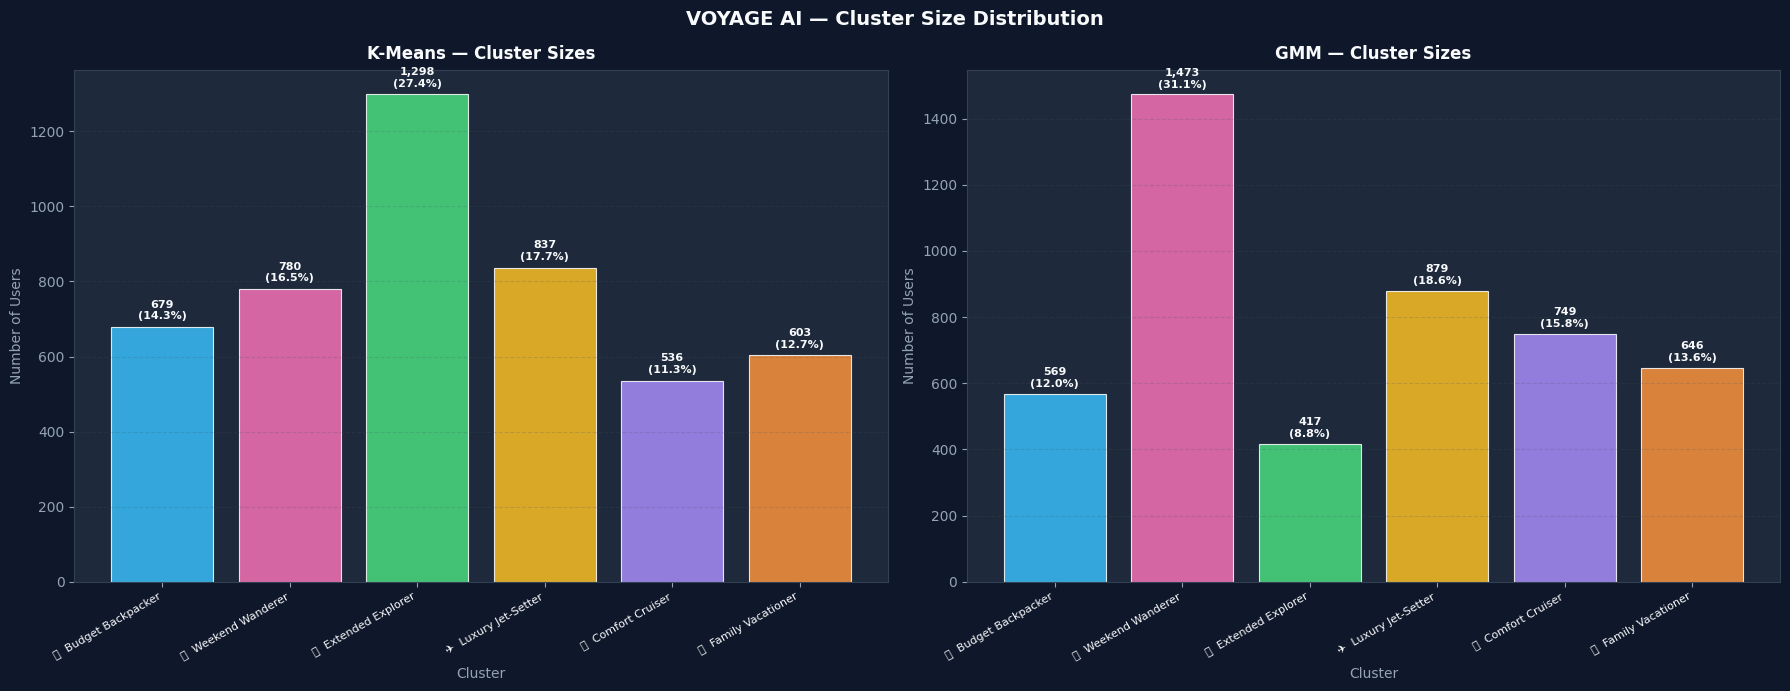

✓ Saved: 03_cluster_sizes.png

  K-MEANS CLUSTER PROFILES
               total_cost_raw         accom_cost_raw         trans_cost_raw         duration          age        accom_share        cost_per_day       
                         mean  median           mean  median           mean  median     mean median  mean median        mean median         mean median
kmeans_cluster                                                                                                                                         
0                       965.0   950.0          576.5   500.0          388.5   381.3      7.2    7.0  28.3   28.0         0.6    0.6        134.7  132.8
1                      2772.4  2700.8         1833.8  1747.8          938.6   850.4      7.2    7.0  42.0   42.0         0.7    0.7        387.6  365.7
2                      1941.6  1800.0         1215.1  1156.9          726.5   700.0      7.0    7.0  30.6   30.7         0.6    0.6        278.1  257.1
3                      1085.4 

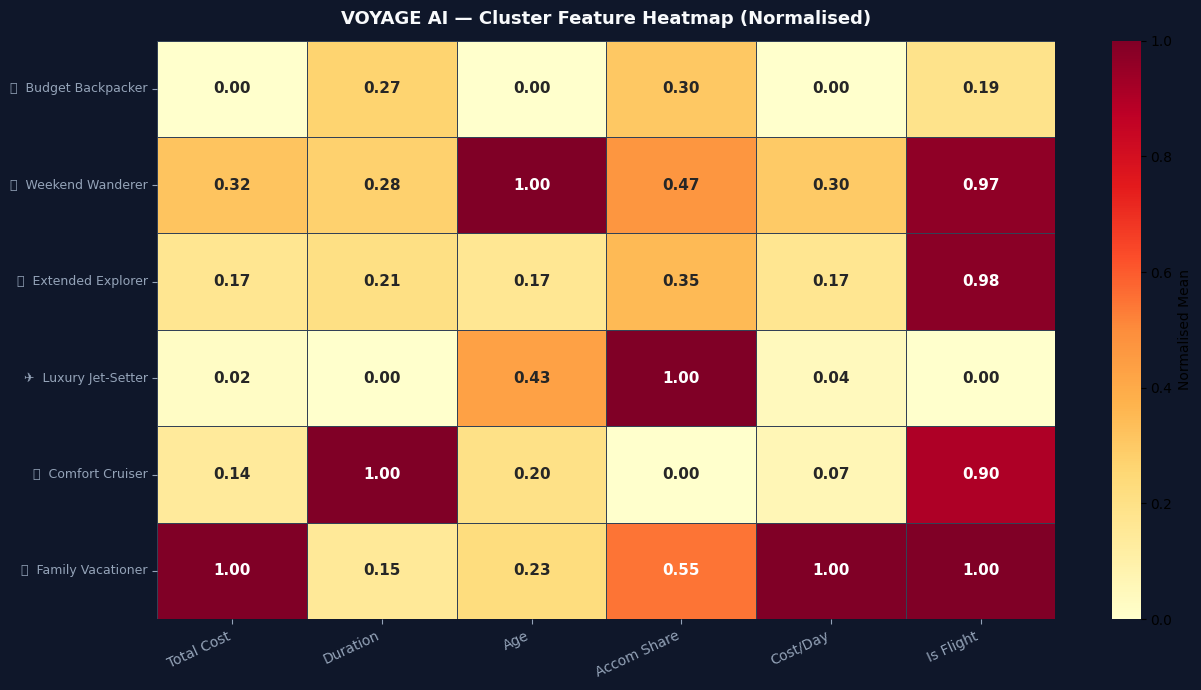

✓ Saved: 04_cluster_heatmap.png


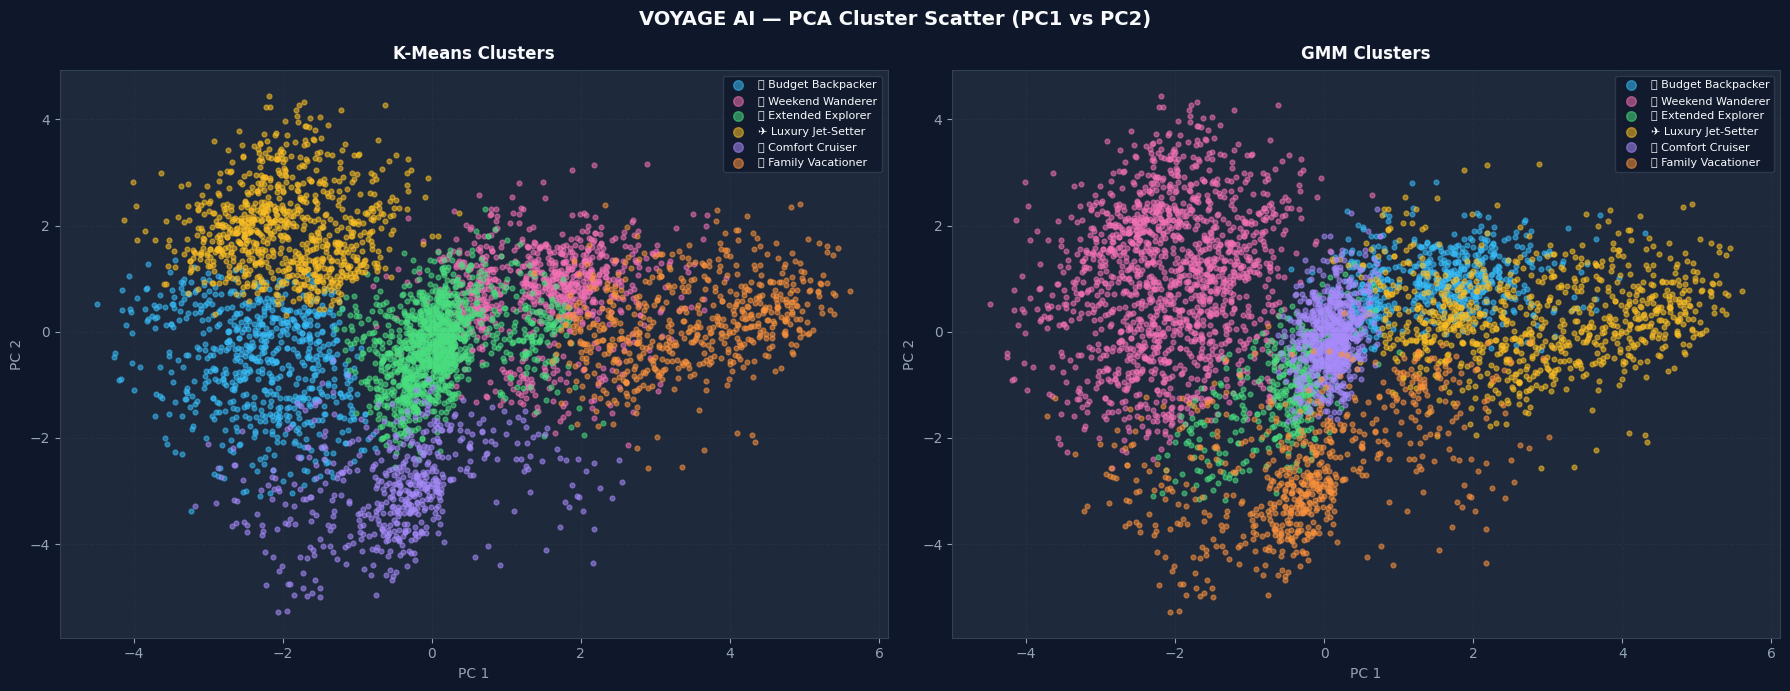

✓ Saved: 05_pca_scatter.png


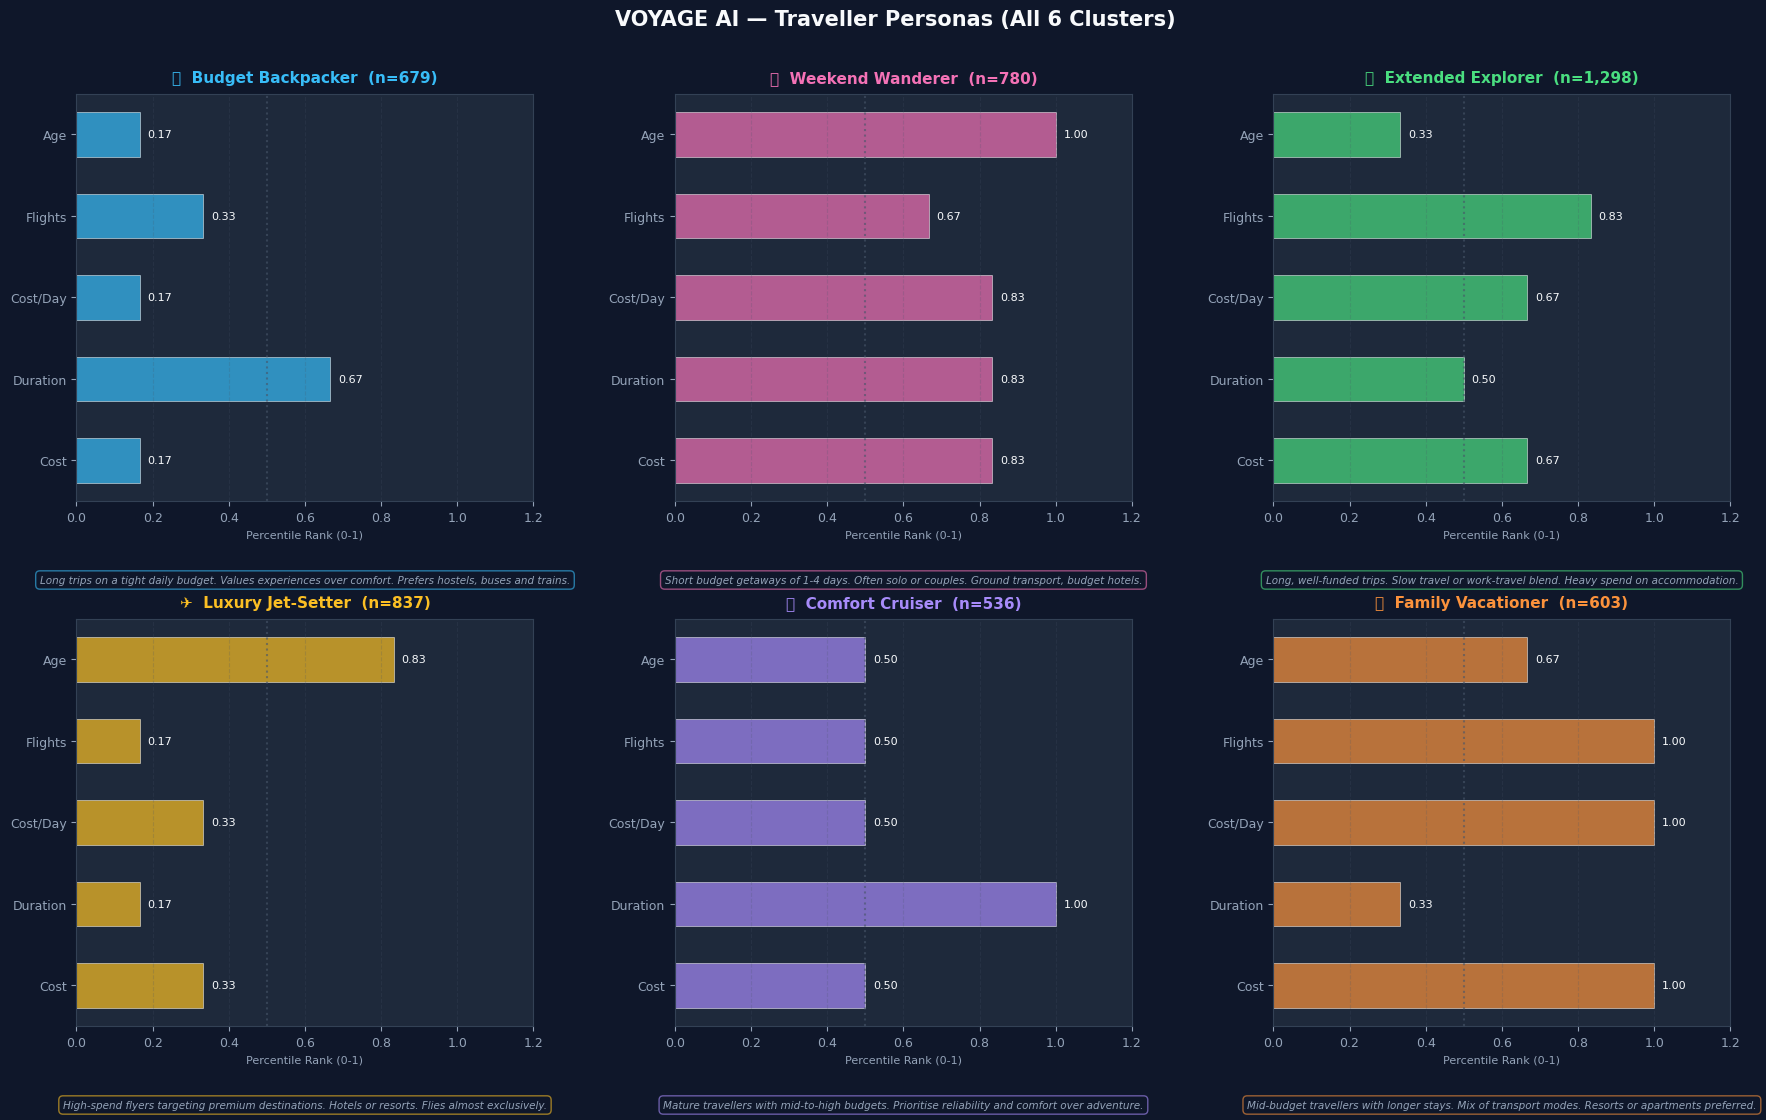

✓ Saved: 06_traveller_personas.png


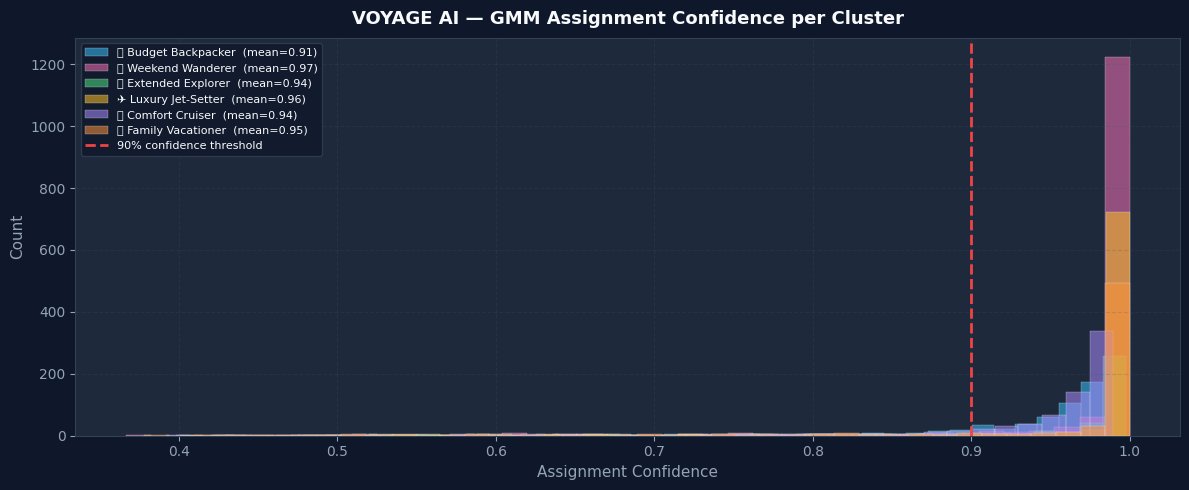

✓ Saved: 07_gmm_confidence.png

  ✓ Step 13 complete — all 6 clusters named and profiled.
  Plots saved: 03_cluster_sizes.png, 04_cluster_heatmap.png,
               05_pca_scatter.png, 06_traveller_personas.png,
               07_gmm_confidence.png


In [16]:
import seaborn as sns

# ── 6 Fixed Cluster Names ────────────────────────────────────────────────────
PERSONA_MAP = {
    0: ('Budget Backpacker', '🏕️',  '#38BDF8', 'Long trips on a tight daily budget. Values experiences over comfort. Prefers hostels, buses and trains.'),
    1: ('Weekend Wanderer',  '🎒',  '#F472B6', 'Short budget getaways of 1-4 days. Often solo or couples. Ground transport, budget hotels.'),
    2: ('Extended Explorer', '🌍',  '#4ADE80', 'Long, well-funded trips. Slow travel or work-travel blend. Heavy spend on accommodation.'),
    3: ('Luxury Jet-Setter', '✈️',  '#FBBF24', 'High-spend flyers targeting premium destinations. Hotels or resorts. Flies almost exclusively.'),
    4: ('Comfort Cruiser',   '🛳️',  '#A78BFA', 'Mature travellers with mid-to-high budgets. Prioritise reliability and comfort over adventure.'),
    5: ('Family Vacationer', '🏖️',  '#FB923C', 'Mid-budget travellers with longer stays. Mix of transport modes. Resorts or apartments preferred.'),
}

BG_DARK    = '#0F172A'
BG_MID     = '#1E293B'
TEXT_LIGHT = '#F8FAFC'
TEXT_DIM   = '#94A3B8'
COLORS     = [PERSONA_MAP[c][2] for c in range(6)]

def cluster_name(c):
    return f"{PERSONA_MAP[c][1]}  {PERSONA_MAP[c][0]}"

# ── Attach labels & decode columns ──────────────────────────────────────────
df_prof = df_clean.copy()
df_prof['kmeans_cluster'] = kmeans_labels
df_prof['gmm_cluster']    = gmm_labels
df_prof['gmm_confidence'] = gmm_conf

accom_map = {i: v for i, v in enumerate(le_accom.classes_)}
trans_map = {i: v for i, v in enumerate(le_trans.classes_)}
df_prof['accom_label']    = df_prof['accom_type'].round().astype(int).map(accom_map)
df_prof['trans_label']    = df_prof['trans_type'].round().astype(int).map(trans_map)
df_prof['total_cost_raw'] = np.expm1(df_prof['log_total'])
df_prof['accom_cost_raw'] = np.expm1(df_prof['log_accom'])
df_prof['trans_cost_raw'] = np.expm1(df_prof['log_trans'])

# ── A: Cluster Size Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG_DARK)
fig.suptitle('VOYAGE AI — Cluster Size Distribution',
             fontsize=14, fontweight='bold', color=TEXT_LIGHT)

for ax, col, title in zip(axes,
                           ['kmeans_cluster', 'gmm_cluster'],
                           ['K-Means', 'GMM']):
    ax.set_facecolor(BG_MID)
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')
    counts = df_prof[col].value_counts().sort_index()
    bars   = ax.bar(counts.index, counts.values,
                    color=COLORS, edgecolor='white', linewidth=0.8, alpha=0.85)
    for bar, (c, v) in zip(bars, counts.items()):
        pct = v / len(df_prof) * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 15,
                f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom', color=TEXT_LIGHT,
                fontsize=8, fontweight='bold')
    ax.set_title(f'{title} — Cluster Sizes', fontweight='bold',
                 color=TEXT_LIGHT, pad=8)
    ax.set_xlabel('Cluster', color=TEXT_DIM)
    ax.set_ylabel('Number of Users', color=TEXT_DIM)
    ax.tick_params(colors=TEXT_DIM)
    ax.grid(axis='y', alpha=0.2, linestyle='--', color='#475569')
    ax.set_xticks(list(range(6)))
    ax.set_xticklabels([cluster_name(i) for i in range(6)],
                       color=TEXT_LIGHT, rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('03_cluster_sizes.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print('✓ Saved: 03_cluster_sizes.png')

# ── B: Printed Cluster Profiles ─────────────────────────────────────────────
print('\n' + '='*70)
print('  K-MEANS CLUSTER PROFILES')
print('='*70)
profile_cols = ['total_cost_raw', 'accom_cost_raw', 'trans_cost_raw',
                'duration', 'age', 'accom_share', 'cost_per_day']
profile = (df_prof.groupby('kmeans_cluster')[profile_cols]
             .agg(['mean', 'median']).round(1))
print(profile.to_string())

print('\n' + '='*70)
print('  PERSONA SUMMARY')
print('='*70)
for c in range(6):
    sub = df_prof[df_prof['kmeans_cluster'] == c]
    name, emoji, color, desc = PERSONA_MAP[c]
    print(f'\n  Cluster {c}: {emoji}  {name}  (n={len(sub):,})')
    print(f'    {desc}')
    print(f'    Avg Total Cost : ${sub["total_cost_raw"].mean():,.0f}')
    print(f'    Avg Duration   : {sub["duration"].mean():.1f} days')
    print(f'    Avg Age        : {sub["age"].mean():.0f} yrs')
    print(f'    Top Accom      : {sub["accom_label"].value_counts().index[0]}')
    print(f'    Top Transport  : {sub["trans_label"].value_counts().index[0]}')

# ── C: Feature Heatmap ──────────────────────────────────────────────────────
heat_cols   = ['total_cost_raw', 'duration', 'age',
               'accom_share', 'cost_per_day', 'is_flight']
heat_labels = ['Total Cost', 'Duration', 'Age',
               'Accom Share', 'Cost/Day', 'Is Flight']

means = df_prof.groupby('kmeans_cluster')[heat_cols].mean()
norm  = (means - means.min()) / (means.max() - means.min() + 1e-9)
norm.columns = heat_labels
norm.index   = [cluster_name(i) for i in range(6)]

fig, ax = plt.subplots(figsize=(13, 7), facecolor=BG_DARK)
ax.set_facecolor(BG_MID)
sns.heatmap(norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#334155', ax=ax,
            cbar_kws={'label': 'Normalised Mean'},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('VOYAGE AI — Cluster Feature Heatmap (Normalised)',
             fontsize=13, fontweight='bold', color=TEXT_LIGHT, pad=12)
ax.set_yticklabels(ax.get_yticklabels(), color=TEXT_LIGHT, rotation=0, fontsize=9)
ax.set_xticklabels(heat_labels, color=TEXT_LIGHT, rotation=25, ha='right')
ax.tick_params(colors=TEXT_DIM)
plt.tight_layout()
plt.savefig('04_cluster_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print('✓ Saved: 04_cluster_heatmap.png')

# ── D: PCA Scatter ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG_DARK)
fig.suptitle('VOYAGE AI — PCA Cluster Scatter (PC1 vs PC2)',
             fontsize=14, fontweight='bold', color=TEXT_LIGHT)

for ax, labels, title in zip(axes,
                               [kmeans_labels, gmm_labels],
                               ['K-Means', 'GMM']):
    ax.set_facecolor(BG_MID)
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')
    for c in range(6):
        mask = labels == c
        name, emoji, color, _ = PERSONA_MAP[c]
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, s=12, alpha=0.55,
                   label=f'{emoji} {name}')
    ax.set_title(f'{title} Clusters', fontweight='bold', color=TEXT_LIGHT, pad=8)
    ax.set_xlabel('PC 1', color=TEXT_DIM)
    ax.set_ylabel('PC 2', color=TEXT_DIM)
    ax.tick_params(colors=TEXT_DIM)
    ax.grid(alpha=0.15, linestyle='--', color='#475569')
    ax.legend(facecolor=BG_DARK, edgecolor='#334155',
              labelcolor=TEXT_LIGHT, fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('05_pca_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print('✓ Saved: 05_pca_scatter.png')

# ── E: Persona Cards (2x3 grid) ──────────────────────────────────────────────
cluster_means = df_prof.groupby('kmeans_cluster').agg(
    total_cost   = ('total_cost_raw', 'mean'),
    duration     = ('duration',       'mean'),
    age          = ('age',            'mean'),
    accom_share  = ('accom_share',    'mean'),
    cost_per_day = ('cost_per_day',   'mean'),
    is_flight    = ('is_flight',      'mean'),
)
cluster_means['cost_rank']   = cluster_means['total_cost'].rank(pct=True)
cluster_means['dur_rank']    = cluster_means['duration'].rank(pct=True)
cluster_means['cpd_rank']    = cluster_means['cost_per_day'].rank(pct=True)
cluster_means['flight_rank'] = cluster_means['is_flight'].rank(pct=True)
cluster_means['age_rank']    = cluster_means['age'].rank(pct=True)

radar_cols  = ['cost_rank', 'dur_rank', 'cpd_rank', 'flight_rank', 'age_rank']
radar_names = ['Cost', 'Duration', 'Cost/Day', 'Flights', 'Age']

fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor=BG_DARK)
fig.suptitle('VOYAGE AI — Traveller Personas (All 6 Clusters)',
             fontsize=15, fontweight='bold', color=TEXT_LIGHT, y=1.01)

for c, ax in enumerate(axes.flatten()):
    name, emoji, color, desc = PERSONA_MAP[c]
    n    = (df_prof['kmeans_cluster'] == c).sum()
    vals = [cluster_means.loc[c, col] for col in radar_cols]
    ax.set_facecolor(BG_MID)
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')
    bars = ax.barh(list(range(5)), vals, color=color,
                   alpha=0.7, edgecolor='white', linewidth=0.5, height=0.55)
    ax.set_xlim(0, 1.2)
    ax.set_yticks(list(range(5)))
    ax.set_yticklabels(radar_names, color=TEXT_LIGHT, fontsize=10)
    ax.tick_params(colors=TEXT_DIM, labelsize=9)
    ax.grid(axis='x', alpha=0.2, linestyle='--', color='#475569')
    ax.axvline(0.5, color='#475569', linestyle=':', alpha=0.6)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{v:.2f}', va='center', color=TEXT_LIGHT, fontsize=8)
    ax.set_title(f'{emoji}  {name}  (n={n:,})',
                 fontsize=11, fontweight='bold', color=color, pad=8)
    ax.set_xlabel('Percentile Rank (0-1)', color=TEXT_DIM, fontsize=8)
    ax.text(0.5, -0.2, desc, transform=ax.transAxes,
            fontsize=7.5, color=TEXT_DIM, ha='center', style='italic',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=BG_DARK,
                      edgecolor=color, alpha=0.6))

plt.tight_layout()
plt.savefig('06_traveller_personas.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print('✓ Saved: 06_traveller_personas.png')

# ── F: GMM Confidence Distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG_DARK)
ax.set_facecolor(BG_MID)
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')
for c in range(6):
    name, emoji, color, _ = PERSONA_MAP[c]
    sub = df_prof[df_prof['gmm_cluster'] == c]['gmm_confidence']
    ax.hist(sub, bins=40, alpha=0.55, color=color,
            edgecolor='white', linewidth=0.3,
            label=f'{emoji} {name}  (mean={sub.mean():.2f})')
ax.axvline(0.9, color='#EF4444', linestyle='--', lw=2,
           label='90% confidence threshold')
ax.set_title('VOYAGE AI — GMM Assignment Confidence per Cluster',
             fontsize=13, fontweight='bold', color=TEXT_LIGHT, pad=10)
ax.set_xlabel('Assignment Confidence', color=TEXT_DIM, fontsize=11)
ax.set_ylabel('Count', color=TEXT_DIM, fontsize=11)
ax.tick_params(colors=TEXT_DIM)
ax.grid(alpha=0.2, linestyle='--', color='#475569')
ax.legend(facecolor=BG_DARK, edgecolor='#334155',
          labelcolor=TEXT_LIGHT, fontsize=8)
plt.tight_layout()
plt.savefig('07_gmm_confidence.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print('✓ Saved: 07_gmm_confidence.png')

print('\n' + '='*70)
print('  ✓ Step 13 complete — all 6 clusters named and profiled.')
print('  Plots saved: 03_cluster_sizes.png, 04_cluster_heatmap.png,')
print('               05_pca_scatter.png, 06_traveller_personas.png,')
print('               07_gmm_confidence.png')
print('='*70)
